Import Libraries

In [1]:
import re
import math
from pathlib import Path
from typing import Optional, Dict, Iterable, List, Tuple, Any
import copy
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import nbinom, lognorm, skewnorm, exponweib
from scipy.optimize import minimize
from scipy.stats import (
    poisson,
    nbinom,
    lognorm,
    gamma as gamma_dist,
    weibull_min,
    skewnorm,
    genpareto,
    burr12,
    kstest,
)

Get Files

In [2]:
FILE_PATH = "/Users/ben/Desktop/Uni/ACTL/ACTL4001/Assignment Information/srcsc-2026-claims-cargo.xlsx"   # <-- change if needed
FREQ_SHEET = "freq"
SEV_SHEET = "sev"

Cleaning Rules

In [3]:
# -------------------------------------------------------------------
# Validation rules based on the Cargo Loss Claims data dictionary
# -------------------------------------------------------------------
NUMERIC_RULES = {
    "weight": (1_500, 250_000),
    "route_risk": (1, 5),
    "distance": (1, 100),
    "transit_duration": (1, 60),
    "pilot_experience": (1, 30),
    "vessel_age": (1, 50),
    "solar_radiation": (0, 1),
    "debris_density": (0, 1),
    "exposure": (0, 1),
    "claim_count": (0, 5),
    "claim_seq": (0, 5),
}

MONEY_RULES_RAW = {
    "cargo_value": (50_000, 680_000_000),
    "claim_amount": (31_000, 678_000_000),
}

NA_LIKE = {"", "na", "n/a", "null", "none", "missing", "nan", "-", "--", "?"}
BAD_PLACEHOLDER_PATTERNS = ["_???", "???"]

COLUMN_ALIASES = {
    "cointainer_type": "container_type",
    "container": "container_type",
    "claim_amount1": "claim_amount",
    "claim amount": "claim_amount",
    "cargo value": "cargo_value",
    "route risk": "route_risk",
    "transit duration": "transit_duration",
    "pilot experience": "pilot_experience",
    "vessel age": "vessel_age",
    "solar radiation": "solar_radiation",
    "debris density": "debris_density",
}

LOWERCASE_CATEGORICAL_COLS = {"origin", "destination", "cargo_type", "container_type"}
INTEGER_LIKE_COLS = {"route_risk", "claim_count"}
STRICT_INTEGER_COLS = {"claim_seq", "claim_count"}  

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)


Cleaning Function

In [4]:
def clean_column_name(col: str) -> str:
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return COLUMN_ALIASES.get(col, col)


def normalise_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [clean_column_name(c) for c in out.columns]
    return out


def add_log(log_rows: List[dict], sheet: str, action: str, rows_removed: int = 0, details: str = "") -> None:
    log_rows.append(
        {
            "sheet": sheet,
            "action": action,
            "rows_removed": int(rows_removed),
            "details": details,
        }
    )


def standardise_strings(df: pd.DataFrame, sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()
    object_like_cols = list(out.select_dtypes(include=["object", "string"]).columns)
    cells_changed = 0

    for col in object_like_cols:
        before = out[col].astype("string")
        s = before.str.strip().str.replace(r"\s+", " ", regex=True)

        na_mask = s.str.lower().isin(NA_LIKE)
        s = s.mask(na_mask, pd.NA)

        if col in LOWERCASE_CATEGORICAL_COLS:
            s = s.str.lower()

        out[col] = s
        after = out[col].astype("string")
        cells_changed += int((before.fillna("<NA>") != after.fillna("<NA>")).sum())

    add_log(log_rows, sheet, "Standardised text fields", 0, f"{cells_changed} cell(s) changed")
    return out


def coerce_numeric_columns(df: pd.DataFrame, numeric_cols: Iterable[str], sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()

    for col in numeric_cols:
        if col not in out.columns:
            continue

        before_na = out[col].isna().sum()
        out[col] = pd.to_numeric(out[col], errors="coerce")
        after_na = out[col].isna().sum()

        new_nas = int(after_na - before_na)
        if new_nas > 0:
            add_log(log_rows, sheet, f"Coerced {col} to numeric", 0, f"{new_nas} value(s) became NaN")

    return out


def infer_money_scale(series: pd.Series, lower_raw: float, upper_raw: float) -> Tuple[float, Dict[float, float]]:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return 1.0, {1.0: np.nan, 1_000.0: np.nan, 1_000_000.0: np.nan}

    candidate_scales = [1.0, 1_000.0, 1_000_000.0]
    fit_scores = {}

    for scale in candidate_scales:
        scaled = values * scale
        fit_scores[scale] = float(((scaled >= lower_raw) & (scaled <= upper_raw)).mean())

    best_scale = max(fit_scores, key=fit_scores.get)
    return best_scale, fit_scores


def standardise_money_columns(df: pd.DataFrame, money_rules_raw: Dict[str, Tuple[float, float]], sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()

    for col, (low_raw, high_raw) in money_rules_raw.items():
        if col not in out.columns:
            continue

        scale, scores = infer_money_scale(out[col], low_raw, high_raw)

        if scale != 1.0:
            out[col] = pd.to_numeric(out[col], errors="coerce") * scale
            add_log(
                log_rows,
                sheet,
                f"Standardised monetary scale for {col}",
                0,
                f"multiplied by {scale:,.0f}; fit scores={scores}",
            )
        else:
            add_log(
                log_rows,
                sheet,
                f"Checked monetary scale for {col}",
                0,
                f"kept as-is; fit scores={scores}",
            )

    return out


def drop_rows_with_bad_placeholders(df: pd.DataFrame, sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()
    object_like_cols = list(out.select_dtypes(include=["object", "string"]).columns)

    if not object_like_cols:
        add_log(log_rows, sheet, "Dropped rows containing bad placeholders", 0, "No object/string columns found")
        return out

    bad_mask = pd.Series(False, index=out.index)

    for col in object_like_cols:
        s = out[col].astype("string")
        col_bad = pd.Series(False, index=out.index)

        for pat in BAD_PLACEHOLDER_PATTERNS:
            col_bad = col_bad | s.str.contains(re.escape(pat), na=False)

        bad_mask = bad_mask | col_bad

    removed = int(bad_mask.sum())
    out = out.loc[~bad_mask].copy()

    add_log(
        log_rows,
        sheet,
        "Dropped rows containing bad placeholders",
        removed,
        f"patterns checked: {BAD_PLACEHOLDER_PATTERNS}",
    )
    return out


def drop_rows_with_any_missing(df: pd.DataFrame, sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()
    missing_mask = out.isna().any(axis=1)
    removed = int(missing_mask.sum())
    out = out.loc[~missing_mask].copy()

    add_log(log_rows, sheet, "Dropped rows with any missing value", removed)
    return out


def drop_exact_duplicates(df: pd.DataFrame, sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()
    dup_mask = out.duplicated(keep="first")
    removed = int(dup_mask.sum())
    out = out.loc[~dup_mask].copy()

    add_log(log_rows, sheet, "Dropped exact duplicate rows", removed)
    return out


def drop_out_of_range(df: pd.DataFrame, rules: Dict[str, Tuple[float, float]], sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()

    for col, (low, high) in rules.items():
        if col not in out.columns:
            continue

        mask = out[col].notna() & ((out[col] < low) | (out[col] > high))
        removed = int(mask.sum())
        out = out.loc[~mask].copy()

        add_log(log_rows, sheet, f"Dropped out-of-range rows for {col}", removed, f"valid range: [{low}, {high}]")

    return out


def cast_integer_like_columns(df: pd.DataFrame, cols: Iterable[str], sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()

    for col in cols:
        if col not in out.columns:
            continue

        non_null = out[col].dropna()
        if non_null.empty:
            continue

        frac_mask = (non_null % 1 != 0)
        bad_frac = int(frac_mask.sum())

        if bad_frac > 0:
            add_log(log_rows, sheet, f"Rounded non-integer values in {col}", 0, f"{bad_frac} row(s) rounded")

        out[col] = out[col].round().astype("Int64")

    return out

def drop_non_integer_rows(df: pd.DataFrame, cols: Iterable[str], sheet: str, log_rows: List[dict]) -> pd.DataFrame:
    out = df.copy()

    for col in cols:
        if col not in out.columns:
            continue

        mask = out[col].notna() & (out[col] % 1 != 0)
        removed = int(mask.sum())
        out = out.loc[~mask].copy()

        add_log(
            log_rows,
            sheet,
            f"Dropped non-integer rows for {col}",
            removed,
            "only integer values allowed",
        )

        if col in out.columns:
            out[col] = out[col].astype("Int64")

    return out


def clean_sheet(df: pd.DataFrame, sheet_name: str) -> Tuple[pd.DataFrame, List[dict], dict]:
    log_rows: List[dict] = []
    before_rows = len(df)

    out = normalise_columns(df)
    add_log(log_rows, sheet_name, "Normalised column names", 0, f"columns={list(out.columns)}")

    out = standardise_strings(out, sheet_name, log_rows)

    numeric_cols = set(NUMERIC_RULES) | set(MONEY_RULES_RAW)
    out = coerce_numeric_columns(out, numeric_cols, sheet_name, log_rows)

    out = standardise_money_columns(out, MONEY_RULES_RAW, sheet_name, log_rows)

    out = drop_rows_with_bad_placeholders(out, sheet_name, log_rows)
    out = drop_rows_with_any_missing(out, sheet_name, log_rows)
    out = drop_exact_duplicates(out, sheet_name, log_rows)

    out = drop_non_integer_rows(out, STRICT_INTEGER_COLS, sheet_name, log_rows)

    out = drop_out_of_range(out, NUMERIC_RULES, sheet_name, log_rows)
    out = drop_out_of_range(out, MONEY_RULES_RAW, sheet_name, log_rows)

    out = cast_integer_like_columns(out, INTEGER_LIKE_COLS, sheet_name, log_rows)

    after_rows = len(out)
    before_after = {
        "sheet": sheet_name,
        "rows_before": before_rows,
        "rows_after": after_rows,
        "rows_removed_total": before_rows - after_rows,
    }

    return out.reset_index(drop=True), log_rows, before_after


def build_summary(log_rows: List[dict], before_after: List[dict]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    actions_df = pd.DataFrame(log_rows)
    before_after_df = pd.DataFrame(before_after)

    if actions_df.empty:
        actions_df = pd.DataFrame(columns=["sheet", "action", "rows_removed", "details"])

    if before_after_df.empty:
        before_after_df = pd.DataFrame(columns=["sheet", "rows_before", "rows_after", "rows_removed_total"])

    return actions_df, before_after_df


def print_section(title: str) -> None:
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


def main() -> None:
    file_path = Path(FILE_PATH)
    if not file_path.exists():
        raise FileNotFoundError(f"Input file not found: {file_path}")

    print_section("READING INPUT FILE")
    print(f"Input file: {file_path}")

    freq_raw = pd.read_excel(file_path, sheet_name=FREQ_SHEET)
    sev_raw = pd.read_excel(file_path, sheet_name=SEV_SHEET)

    print(f"{FREQ_SHEET}: {len(freq_raw):,} rows loaded")
    print(f"{SEV_SHEET}: {len(sev_raw):,} rows loaded")

    freq_clean, freq_log, freq_before_after = clean_sheet(freq_raw, FREQ_SHEET)
    sev_clean, sev_log, sev_before_after = clean_sheet(sev_raw, SEV_SHEET)

    combined_log = freq_log + sev_log
    before_after_rows = [freq_before_after, sev_before_after]

    actions_df, before_after_df = build_summary(combined_log, before_after_rows)
    actions_df = actions_df[["sheet", "action", "rows_removed", "details"]]
    before_after_df = before_after_df[["sheet", "rows_before", "rows_after", "rows_removed_total"]]

    output_path = Path("/Users/ben/Desktop/Uni/ACTL/ACTL4001/Assignment Code/Basic Data Cleaning and Modeling/srcsc-2026-claims-cargo_cleaned.xlsx")
    
    print_section("CLEANING ACTIONS")
    if len(actions_df) == 0:
        print("No cleaning actions recorded.")
    else:
        print(actions_df.to_string(index=False))

    print_section("BEFORE / AFTER ROW COUNTS")
    print(before_after_df.to_string(index=False))

    print_section("WRITING CLEAN FILE")
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        freq_clean.to_excel(writer, sheet_name=FREQ_SHEET, index=False)
        sev_clean.to_excel(writer, sheet_name=SEV_SHEET, index=False)
        before_after_df.to_excel(writer, sheet_name="row_summary", index=False)
        actions_df.to_excel(writer, sheet_name="cleaning_summary", index=False)

    print(f"Cleaned workbook saved to: {output_path}")

    print_section("FINAL OUTPUT")
    print(f"{FREQ_SHEET}: {len(freq_raw):,} -> {len(freq_clean):,} rows")
    print(f"{SEV_SHEET}: {len(sev_raw):,} -> {len(sev_clean):,} rows")
    print(f"Total rows removed: {(len(freq_raw) - len(freq_clean)) + (len(sev_raw) - len(sev_clean)):,}")


if __name__ == "__main__":
    main()


READING INPUT FILE
Input file: /Users/ben/Desktop/Uni/ACTL/ACTL4001/Assignment Information/srcsc-2026-claims-cargo.xlsx
freq: 124,982 rows loaded
sev: 30,650 rows loaded

CLEANING ACTIONS
sheet                                         action  rows_removed                                                                                                                                                                                                                                                                 details
 freq                        Normalised column names             0                           columns=['policy_id', 'shipment_id', 'cargo_type', 'cargo_value', 'weight', 'route_risk', 'distance', 'transit_duration', 'pilot_experience', 'vessel_age', 'container_type', 'solar_radiation', 'debris_density', 'exposure', 'claim_count']
 freq                       Standardised text fields             0                                                                                   

Fitting Models to frequency and severity data

In [5]:
# ============================================================
# CONFIG
# ============================================================
CLEANED_FILE = Path(
    "/Users/ben/Desktop/Uni/ACTL/ACTL4001/Assignment Code/Basic Data Cleaning and Modeling/srcsc-2026-claims-cargo_cleaned.xlsx"
)

FREQ_SHEET = "freq"
SEV_SHEET = "sev"

TEST_SIZE = 0.20
RANDOM_SEED = 42

# Candidate alpha values for NB GLM search
NB_ALPHA_GRID = [0.05, 0.10, 0.20, 0.50, 1.00, 2.00, 5.00]

# Candidate thresholds for spliced severity fit
SPLICE_THRESHOLD_GRID = (0.85, 0.90, 0.95)


# ============================================================
# HELPERS
# ============================================================
def find_first_existing_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def normalise_cargo_label(x: str) -> str:
    x = str(x).strip().lower()
    replacements = {
        "rare earth": "rare earths",
        "rare-earths": "rare earths",
        "rare_earths": "rare earths",
    }
    return replacements.get(x, x)


def safe_numeric(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def train_test_split_df(df: pd.DataFrame, test_size: float = 0.20, seed: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.RandomState(seed)
    idx = np.arange(len(df))
    rng.shuffle(idx)

    n_test = int(round(len(df) * test_size))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()
    return train_df, test_df


def build_formula(response: str, numeric_cols: List[str], categorical_cols: List[str]) -> str:
    terms = []
    terms.extend(numeric_cols)
    terms.extend(["C({0})".format(c) for c in categorical_cols])

    if len(terms) == 0:
        return "{0} ~ 1".format(response)

    return "{0} ~ {1}".format(response, " + ".join(terms))


def extract_pvalue_table(model) -> pd.DataFrame:
    out = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "stat": model.tvalues.values if hasattr(model, "tvalues") else np.nan,
        "p_value": model.pvalues.values,
    })

    if hasattr(model, "conf_int"):
        ci = model.conf_int()
        out["ci_low"] = ci.iloc[:, 0].values
        out["ci_high"] = ci.iloc[:, 1].values

    return out.sort_values(["p_value", "term"]).reset_index(drop=True)


def mean_deviance(model, y_true: np.ndarray, mu_pred: np.ndarray) -> float:
    try:
        dev = model.family.deviance(y_true, mu_pred)
        return float(dev) / len(y_true)
    except Exception:
        return np.nan


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def available_predictors(
    df: pd.DataFrame,
    numeric_candidates: List[str],
    categorical_candidates: List[str],
) -> Tuple[List[str], List[str]]:
    numeric_cols = [c for c in numeric_candidates if c in df.columns]
    categorical_cols = [c for c in categorical_candidates if c in df.columns]
    return numeric_cols, categorical_cols


# ============================================================
# LOAD DATA
# ============================================================
def load_clean_data(file_path: Path) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, Any]]:
    freq_df = pd.read_excel(file_path, sheet_name=FREQ_SHEET)
    sev_df = pd.read_excel(file_path, sheet_name=SEV_SHEET)

    freq_df = freq_df.loc[:, ~freq_df.columns.duplicated()].copy()
    sev_df = sev_df.loc[:, ~sev_df.columns.duplicated()].copy()

    cargo_candidates = ["cargo_type", "cargo", "cargo_category", "type_of_cargo"]
    freq_candidates = ["claim_count", "claims_count", "n_claims", "claim_num", "claim_frequency"]
    sev_candidates = ["claim_amount", "severity", "claim_size", "loss_amount", "paid_amount"]
    exposure_candidates = ["exposure", "policy_exposure"]

    freq_cargo_col = find_first_existing_column(freq_df, cargo_candidates)
    sev_cargo_col = find_first_existing_column(sev_df, cargo_candidates)
    freq_count_col = find_first_existing_column(freq_df, freq_candidates)
    sev_amount_col = find_first_existing_column(sev_df, sev_candidates)
    exposure_col = find_first_existing_column(freq_df, exposure_candidates)

    if freq_cargo_col is None or sev_cargo_col is None:
        raise ValueError("Could not find cargo_type column in one or both sheets.")
    if freq_count_col is None:
        raise ValueError("Could not find claim_count column in freq sheet.")
    if sev_amount_col is None:
        raise ValueError("Could not find claim_amount column in sev sheet.")

    freq_df[freq_cargo_col] = freq_df[freq_cargo_col].astype(str).map(normalise_cargo_label)
    sev_df[sev_cargo_col] = sev_df[sev_cargo_col].astype(str).map(normalise_cargo_label)

    freq_df = safe_numeric(
        freq_df,
        [freq_count_col, exposure_col, "cargo_value", "weight", "distance", "transit_duration",
         "pilot_experience", "vessel_age", "solar_radiation", "debris_density"]
    )

    sev_df = safe_numeric(
        sev_df,
        [sev_amount_col, "cargo_value", "weight", "distance", "transit_duration",
         "pilot_experience", "vessel_age", "solar_radiation", "debris_density", "claim_seq"]
    )

    # Frequency cleaning
    freq_df = freq_df.dropna(subset=[freq_cargo_col, freq_count_col]).copy()
    freq_df = freq_df[freq_df[freq_count_col] >= 0].copy()
    freq_df = freq_df[np.isclose(freq_df[freq_count_col], np.round(freq_df[freq_count_col]))].copy()
    freq_df[freq_count_col] = freq_df[freq_count_col].astype(int)

    # Severity cleaning
    sev_df = sev_df.dropna(subset=[sev_cargo_col, sev_amount_col]).copy()
    sev_df = sev_df[sev_df[sev_amount_col] > 0].copy()

    meta = {
        "freq_cargo_col": freq_cargo_col,
        "sev_cargo_col": sev_cargo_col,
        "freq_count_col": freq_count_col,
        "sev_amount_col": sev_amount_col,
        "exposure_col": exposure_col,
    }

    return freq_df, sev_df, meta


# ============================================================
# FREQUENCY DISTRIBUTIONS
# ============================================================
def nb2_neg_loglik(params: np.ndarray, y: np.ndarray) -> float:
    log_mu, log_alpha = params
    mu = np.exp(log_mu)
    alpha = np.exp(log_alpha)

    if (not np.isfinite(mu)) or (not np.isfinite(alpha)) or (mu <= 0) or (alpha <= 0):
        return np.inf

    r = 1.0 / alpha
    p = r / (r + mu)

    return -np.sum(nbinom.logpmf(y, n=r, p=p))


def fit_frequency_distributions(freq_df: pd.DataFrame, count_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    y = freq_df[count_col].to_numpy()
    n = len(y)

    rows = []

    # Poisson
    lam = float(np.mean(y))
    ll = float(np.sum(poisson.logpmf(y, mu=lam)))
    rows.append({
        "model": "Poisson",
        "n": n,
        "loglik": ll,
        "aic": 2 * 1 - 2 * ll,
        "bic": math.log(n) * 1 - 2 * ll,
        "mean": lam,
        "alpha": np.nan,
        "size_r": np.nan,
        "pred_zero_pct": 100 * float(poisson.pmf(0, mu=lam)),
        "observed_zero_pct": 100 * float(np.mean(y == 0)),
    })

    # Negative Binomial
    y_mean = float(np.mean(y))
    y_var = float(np.var(y, ddof=1))
    alpha_start = max((y_var - y_mean) / max(y_mean ** 2, 1e-12), 1e-8)

    res = minimize(
        nb2_neg_loglik,
        x0=np.array([np.log(max(y_mean, 1e-8)), np.log(alpha_start)]),
        args=(y,),
        method="L-BFGS-B",
    )

    if res.success:
        mu_nb = float(np.exp(res.x[0]))
        alpha_nb = float(np.exp(res.x[1]))
        r_nb = 1.0 / alpha_nb
        p_nb = r_nb / (r_nb + mu_nb)
        ll_nb = -float(res.fun)

        rows.append({
            "model": "Negative Binomial",
            "n": n,
            "loglik": ll_nb,
            "aic": 2 * 2 - 2 * ll_nb,
            "bic": math.log(n) * 2 - 2 * ll_nb,
            "mean": mu_nb,
            "alpha": alpha_nb,
            "size_r": r_nb,
            "pred_zero_pct": 100 * float(nbinom.pmf(0, n=r_nb, p=p_nb)),
            "observed_zero_pct": 100 * float(np.mean(y == 0)),
        })

    out = pd.DataFrame(rows).sort_values(["aic", "bic"]).reset_index(drop=True)
    best = out.iloc[0]
    return out, best


# ============================================================
# SEVERITY DISTRIBUTIONS
# ============================================================
def fit_lognormal_dist(x: np.ndarray) -> Dict[str, Any]:
    logx = np.log(x)
    mu = float(np.mean(logx))
    sigma = float(np.std(logx, ddof=0))

    if sigma <= 0:
        raise ValueError("sigma <= 0")

    ll = float(np.sum(lognorm.logpdf(x, s=sigma, scale=np.exp(mu))))
    n = len(x)

    def cdf(v):
        return lognorm.cdf(v, s=sigma, scale=np.exp(mu))

    return {
        "model": "lognormal",
        "loglik": ll,
        "aic": 2 * 2 - 2 * ll,
        "bic": math.log(n) * 2 - 2 * ll,
        "ks_stat": float(kstest(x, cdf).statistic),
        "ks_pvalue": float(kstest(x, cdf).pvalue),
        "params": str({"mu_log": mu, "sigma_log": sigma}),
    }


def fit_gamma_distn(x: np.ndarray) -> Dict[str, Any]:
    a, loc, scale = gamma_dist.fit(x, floc=0)
    a = float(a)
    scale = float(scale)
    ll = float(np.sum(gamma_dist.logpdf(x, a=a, loc=0, scale=scale)))
    n = len(x)

    def cdf(v):
        return gamma_dist.cdf(v, a=a, loc=0, scale=scale)

    return {
        "model": "gamma",
        "loglik": ll,
        "aic": 2 * 2 - 2 * ll,
        "bic": math.log(n) * 2 - 2 * ll,
        "ks_stat": float(kstest(x, cdf).statistic),
        "ks_pvalue": float(kstest(x, cdf).pvalue),
        "params": str({"shape": a, "scale": scale}),
    }


def fit_weibull_distn(x: np.ndarray) -> Dict[str, Any]:
    c, loc, scale = weibull_min.fit(x, floc=0)
    c = float(c)
    scale = float(scale)
    ll = float(np.sum(weibull_min.logpdf(x, c=c, loc=0, scale=scale)))
    n = len(x)

    def cdf(v):
        return weibull_min.cdf(v, c=c, loc=0, scale=scale)

    return {
        "model": "weibull_min",
        "loglik": ll,
        "aic": 2 * 2 - 2 * ll,
        "bic": math.log(n) * 2 - 2 * ll,
        "ks_stat": float(kstest(x, cdf).statistic),
        "ks_pvalue": float(kstest(x, cdf).pvalue),
        "params": str({"shape": c, "scale": scale}),
    }


def fit_log_skew_normal_dist(x: np.ndarray) -> Dict[str, Any]:
    logx = np.log(x)
    a, loc, scale = skewnorm.fit(logx)
    a = float(a)
    loc = float(loc)
    scale = float(scale)

    if scale <= 0:
        raise ValueError("scale <= 0")

    ll = float(np.sum(skewnorm.logpdf(logx, a=a, loc=loc, scale=scale) - logx))
    n = len(x)

    def cdf(v):
        v = np.asarray(v)
        out = np.zeros_like(v, dtype=float)
        mask = v > 0
        out[mask] = skewnorm.cdf(np.log(v[mask]), a=a, loc=loc, scale=scale)
        return out

    return {
        "model": "log_skew_normal",
        "loglik": ll,
        "aic": 2 * 3 - 2 * ll,
        "bic": math.log(n) * 3 - 2 * ll,
        "ks_stat": float(kstest(x, cdf).statistic),
        "ks_pvalue": float(kstest(x, cdf).pvalue),
        "params": str({"shape": a, "loc_log": loc, "scale_log": scale}),
    }


def fit_burr12_dist(x: np.ndarray) -> Dict[str, Any]:
    c, d, loc, scale = burr12.fit(x, floc=0)
    c = float(c)
    d = float(d)
    scale = float(scale)

    ll = float(np.sum(burr12.logpdf(x, c=c, d=d, loc=0, scale=scale)))
    n = len(x)

    def cdf(v):
        return burr12.cdf(v, c=c, d=d, loc=0, scale=scale)

    return {
        "model": "burr12",
        "loglik": ll,
        "aic": 2 * 3 - 2 * ll,
        "bic": math.log(n) * 3 - 2 * ll,
        "ks_stat": float(kstest(x, cdf).statistic),
        "ks_pvalue": float(kstest(x, cdf).pvalue),
        "params": str({"c": c, "d": d, "scale": scale}),
    }


def fit_spliced_lognormal_gpd_dist(
    x: np.ndarray,
    threshold_grid: Tuple[float, ...] = (0.85, 0.90, 0.95),
) -> Dict[str, Any]:
    best = None

    for q in threshold_grid:
        u = float(np.quantile(x, q))
        body = x[x <= u]
        tail = x[x > u]

        if len(body) < 30 or len(tail) < 10:
            continue

        log_body = np.log(body)
        mu = float(np.mean(log_body))
        sigma = float(np.std(log_body, ddof=0))

        if sigma <= 0:
            continue

        F_u = float(lognorm.cdf(u, s=sigma, scale=np.exp(mu)))
        if F_u <= 0 or F_u >= 1:
            continue

        excess = tail - u
        xi, loc, beta = genpareto.fit(excess, floc=0)
        xi = float(xi)
        beta = float(beta)

        if beta <= 0:
            continue

        w_body = float(len(body)) / float(len(x))

        ll_body = np.sum(
            np.log(w_body)
            + lognorm.logpdf(body, s=sigma, scale=np.exp(mu))
            - np.log(F_u)
        )

        ll_tail = np.sum(
            np.log(1 - w_body)
            + genpareto.logpdf(excess, c=xi, loc=0, scale=beta)
        )

        ll = float(ll_body + ll_tail)

        def cdf(v, u=u, w_body=w_body, mu=mu, sigma=sigma, F_u=F_u, xi=xi, beta=beta):
            v = np.asarray(v, dtype=float)
            out = np.zeros_like(v)

            mask1 = (v > 0) & (v <= u)
            mask2 = v > u

            out[mask1] = w_body * lognorm.cdf(v[mask1], s=sigma, scale=np.exp(mu)) / F_u
            out[mask2] = w_body + (1 - w_body) * genpareto.cdf(
                v[mask2] - u, c=xi, loc=0, scale=beta
            )
            return out

        ks = kstest(x, cdf)

        candidate = {
            "model": "spliced_lognormal_gpd",
            "loglik": ll,
            "aic": 2 * 5 - 2 * ll,
            "bic": math.log(len(x)) * 5 - 2 * ll,
            "ks_stat": float(ks.statistic),
            "ks_pvalue": float(ks.pvalue),
            "params": str({
                "threshold_quantile": q,
                "threshold_u": u,
                "body_weight": w_body,
                "mu_log": mu,
                "sigma_log": sigma,
                "gpd_shape": xi,
                "gpd_scale": beta,
            }),
        }

        if (best is None) or (candidate["aic"] < best["aic"]):
            best = candidate

    if best is None:
        raise ValueError("No valid splice fit found.")

    return best


def fit_one_severity_candidate_set(x: np.ndarray) -> pd.DataFrame:
    fitters = [
        fit_lognormal_dist,
        fit_gamma_distn,
        fit_weibull_distn,
        fit_log_skew_normal_dist,
        fit_burr12_dist,
        fit_spliced_lognormal_gpd_dist,
    ]

    rows = []
    for fitter in fitters:
        try:
            rows.append(fitter(x))
        except Exception as e:
            rows.append({
                "model": fitter.__name__.replace("fit_", "").replace("_distn", "").replace("_dist", ""),
                "loglik": np.nan,
                "aic": np.nan,
                "bic": np.nan,
                "ks_stat": np.nan,
                "ks_pvalue": np.nan,
                "params": "FAILED: {0}".format(str(e)),
            })

    out = pd.DataFrame(rows)
    out = out.dropna(subset=["aic"]).sort_values(["aic", "bic", "ks_stat"]).reset_index(drop=True)
    return out


def fit_severity_distributions(
    sev_df: pd.DataFrame,
    cargo_col: str,
    amount_col: str,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    all_rows = []
    best_rows = []

    cargo_values = sorted(sev_df[cargo_col].dropna().unique())

    for cargo in cargo_values:
        x = sev_df.loc[sev_df[cargo_col] == cargo, amount_col].to_numpy(dtype=float)
        x = x[np.isfinite(x) & (x > 0)]

        if len(x) < 20:
            continue

        result = fit_one_severity_candidate_set(x)
        result.insert(0, "cargo_type", cargo)
        all_rows.append(result)

        best_rows.append(result.iloc[0].copy())

    all_results = pd.concat(all_rows, axis=0).reset_index(drop=True)
    best_results = pd.DataFrame(best_rows).reset_index(drop=True)

    return all_results, best_results


# ============================================================
# FREQUENCY GLMS
# ============================================================
def fit_frequency_glms(
    freq_df: pd.DataFrame,
    count_col: str,
    exposure_col: Optional[str],
) -> Tuple[pd.DataFrame, Any, pd.DataFrame]:
    numeric_candidates = [
        "cargo_value",
        "weight",
        "distance",
        "transit_duration",
        "pilot_experience",
        "vessel_age",
        "solar_radiation",
        "debris_density",
    ]

    categorical_candidates = [
        "route_risk",
        "cargo_type",
        "container_type",
    ]

    numeric_cols, categorical_cols = available_predictors(
        freq_df, numeric_candidates, categorical_candidates
    )

    formula = build_formula(count_col, numeric_cols, categorical_cols)

    train_df, test_df = train_test_split_df(freq_df, test_size=TEST_SIZE, seed=RANDOM_SEED)

    train_offset = None
    test_offset = None
    if exposure_col is not None and exposure_col in freq_df.columns:
        train_offset = np.log(pd.to_numeric(train_df[exposure_col], errors="coerce").fillna(0.0).clip(lower=1e-9))
        test_offset = np.log(pd.to_numeric(test_df[exposure_col], errors="coerce").fillna(0.0).clip(lower=1e-9))

    rows = []

    # Poisson GLM
    pois_model = smf.glm(
        formula=formula,
        data=train_df,
        family=sm.families.Poisson(),
        offset=train_offset,
    ).fit()

    mu_test = pois_model.predict(test_df, offset=test_offset)
    rows.append({
        "model": "Poisson GLM",
        "alpha": np.nan,
        "formula": formula,
        "train_aic": float(pois_model.aic),
        "train_bic": np.nan,
        "test_mean_deviance": mean_deviance(pois_model, test_df[count_col].to_numpy(), np.asarray(mu_test)),
        "test_rmse": rmse(test_df[count_col].to_numpy(), np.asarray(mu_test)),
    })

    best_model = pois_model
    best_score = rows[-1]["test_mean_deviance"]

    # NB GLM over alpha grid
    for alpha in NB_ALPHA_GRID:
        try:
            nb_model = smf.glm(
                formula=formula,
                data=train_df,
                family=sm.families.NegativeBinomial(alpha=alpha),
                offset=train_offset,
            ).fit()

            mu_test = nb_model.predict(test_df, offset=test_offset)
            score = mean_deviance(nb_model, test_df[count_col].to_numpy(), np.asarray(mu_test))

            rows.append({
                "model": "Negative Binomial GLM",
                "alpha": alpha,
                "formula": formula,
                "train_aic": float(nb_model.aic),
                "train_bic": np.nan,
                "test_mean_deviance": score,
                "test_rmse": rmse(test_df[count_col].to_numpy(), np.asarray(mu_test)),
            })

            if (np.isfinite(score)) and (score < best_score):
                best_score = score
                best_model = nb_model

        except Exception:
            continue

    results = pd.DataFrame(rows).sort_values(["test_mean_deviance", "train_aic"]).reset_index(drop=True)
    pvalues = extract_pvalue_table(best_model)

    return results, best_model, pvalues


# ============================================================
# SEVERITY GLMS
# ============================================================
def fit_severity_glms(
    sev_df: pd.DataFrame,
    amount_col: str,
) -> Tuple[pd.DataFrame, Any, pd.DataFrame]:
    sev_work = sev_df.copy()
    sev_work = sev_work[sev_work[amount_col] > 0].copy()

    numeric_candidates = [
        "cargo_value",
        "weight",
        "distance",
        "transit_duration",
        "pilot_experience",
        "vessel_age",
        "solar_radiation",
        "debris_density",
        "claim_seq",
    ]

    categorical_candidates = [
        "route_risk",
        "cargo_type",
        "container_type",
    ]

    numeric_cols, categorical_cols = available_predictors(
        sev_work, numeric_candidates, categorical_candidates
    )

    formula = build_formula(amount_col, numeric_cols, categorical_cols)

    train_df, test_df = train_test_split_df(sev_work, test_size=TEST_SIZE, seed=RANDOM_SEED)

    rows = []

    # Gamma log-link
    gamma_model = smf.glm(
        formula=formula,
        data=train_df,
        family=sm.families.Gamma(sm.families.links.log()),
    ).fit()

    mu_test = gamma_model.predict(test_df)
    rows.append({
        "model": "Gamma GLM",
        "link": "log",
        "formula": formula,
        "train_aic": float(gamma_model.aic),
        "test_mean_deviance": mean_deviance(gamma_model, test_df[amount_col].to_numpy(), np.asarray(mu_test)),
        "test_rmse": rmse(test_df[amount_col].to_numpy(), np.asarray(mu_test)),
    })

    best_model = gamma_model
    best_score = rows[-1]["test_mean_deviance"]

    # Inverse Gaussian log-link
    try:
        ig_model = smf.glm(
            formula=formula,
            data=train_df,
            family=sm.families.InverseGaussian(sm.families.links.log()),
        ).fit()

        mu_test = ig_model.predict(test_df)
        score = mean_deviance(ig_model, test_df[amount_col].to_numpy(), np.asarray(mu_test))

        rows.append({
            "model": "Inverse Gaussian GLM",
            "link": "log",
            "formula": formula,
            "train_aic": float(ig_model.aic),
            "test_mean_deviance": score,
            "test_rmse": rmse(test_df[amount_col].to_numpy(), np.asarray(mu_test)),
        })

        if (np.isfinite(score)) and (score < best_score):
            best_score = score
            best_model = ig_model

    except Exception:
        pass

    results = pd.DataFrame(rows).sort_values(["test_mean_deviance", "train_aic"]).reset_index(drop=True)
    pvalues = extract_pvalue_table(best_model)

    return results, best_model, pvalues


# ============================================================
# RUN
# ============================================================
freq_df, sev_df, meta = load_clean_data(CLEANED_FILE)

print("\nDetected columns")
print(pd.Series(meta))

# ----------------------------
# 1. Best frequency distribution
# ----------------------------
freq_dist_results, best_freq_dist = fit_frequency_distributions(
    freq_df=freq_df,
    count_col=meta["freq_count_col"],
)

print("\n=== FREQUENCY DISTRIBUTION CANDIDATES ===")
print(freq_dist_results.round(6))
print("\nBest frequency distribution:")
print(best_freq_dist)

# ----------------------------
# 2. Best severity distribution by cargo type
# ----------------------------
sev_dist_all, sev_dist_best = fit_severity_distributions(
    sev_df=sev_df,
    cargo_col=meta["sev_cargo_col"],
    amount_col=meta["sev_amount_col"],
)

print("\n=== SEVERITY DISTRIBUTION CANDIDATES (ALL) ===")
print(sev_dist_all.round(6))

print("\n=== BEST SEVERITY DISTRIBUTION BY CARGO TYPE ===")
print(sev_dist_best.round(6))



Detected columns
freq_cargo_col      cargo_type
sev_cargo_col       cargo_type
freq_count_col     claim_count
sev_amount_col    claim_amount
exposure_col          exposure
dtype: object

=== FREQUENCY DISTRIBUTION CANDIDATES ===
               model       n        loglik            aic            bic      mean     alpha    size_r  pred_zero_pct  observed_zero_pct
0  Negative Binomial  117163 -71940.298370  143884.596740  143903.939382  0.244788  1.863151  0.536725      81.736253          81.771549
1            Poisson  117163 -75015.950836  150033.901672  150043.572994  0.244787       NaN       NaN      78.287113          81.771549

Best frequency distribution:
model                Negative Binomial
n                               117163
loglik                    -71940.29837
aic                       143884.59674
bic                      143903.939382
mean                          0.244788
alpha                         1.863151
size_r                        0.536725
pred_zero_pct    

/opt/anaconda3/envs/fins3640/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:1315: RuntimeWarning: overflow encountered in power
  return np.log(c) + np.log(d) + sc.xlogy(c - 1, x) + sc.xlog1py(-d-1, x**c)
/opt/anaconda3/envs/fins3640/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:1315: RuntimeWarning: overflow encountered in power
  return np.log(c) + np.log(d) + sc.xlogy(c - 1, x) + sc.xlog1py(-d-1, x**c)
/opt/anaconda3/envs/fins3640/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:1315: RuntimeWarning: overflow encountered in power
  return np.log(c) + np.log(d) + sc.xlogy(c - 1, x) + sc.xlog1py(-d-1, x**c)
/opt/anaconda3/envs/fins3640/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:1315: RuntimeWarning: overflow encountered in power
  return np.log(c) + np.log(d) + sc.xlogy(c - 1, x) + sc.xlog1py(-d-1, x**c)
/opt/anaconda3/envs/fins3640/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:1315: RuntimeWarning: ov


=== SEVERITY DISTRIBUTION CANDIDATES (ALL) ===
     cargo_type                  model        loglik            aic            bic   ks_stat  ks_pvalue  \
0        cobalt              lognormal -57260.847388  114525.694777  114538.281375  0.008189   0.949436   
1        cobalt        log_skew_normal -57260.840857  114527.681715  114546.561613  0.008020   0.957419   
2        cobalt  spliced_lognormal_gpd -57292.314042  114594.628084  114626.094581  0.044801   0.000000   
3        cobalt                  gamma -57503.002853  115010.005706  115022.592305  0.064963   0.000000   
4        cobalt            weibull_min -57601.784967  115207.569934  115220.156533  0.067035   0.000000   
5        cobalt                 burr12 -64193.648851  128393.297703  128412.177601  0.512389   0.000000   
6          gold        log_skew_normal -75261.890605  150529.781210  150548.720561  0.010522   0.753261   
7          gold              lognormal -75264.069716  150532.139433  150544.765666  0.014542   0

QQ Plot of Models

Using cargo column: cargo_type
Using severity column: claim_amount
Unique cargo types in data: ['cobalt', 'gold', 'lithium', 'platinum', 'rare earths', 'supplies', 'titanium']


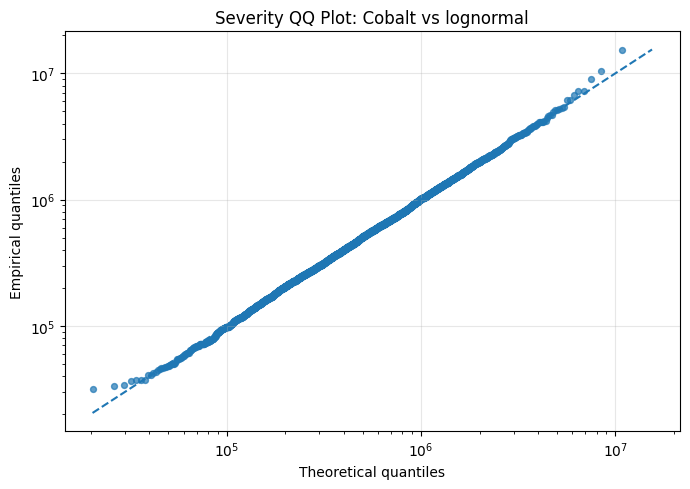

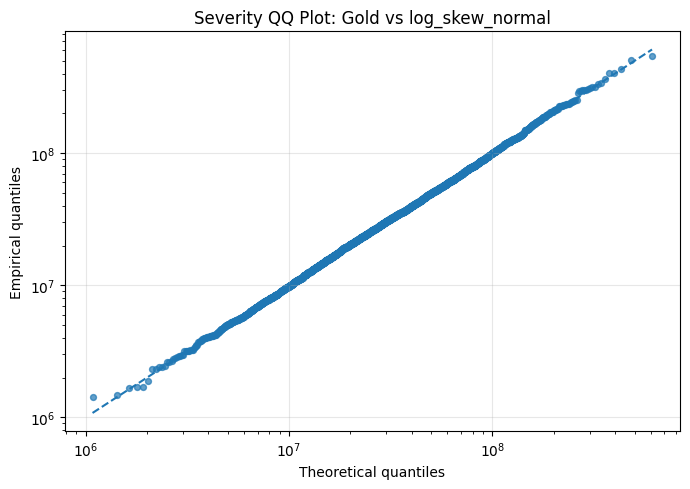

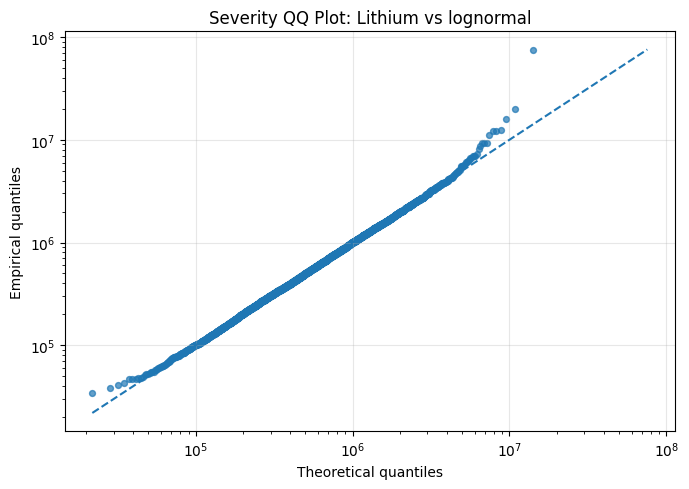

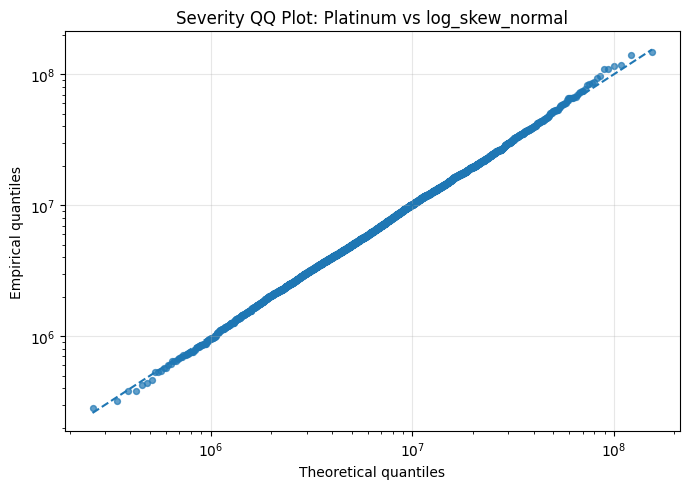

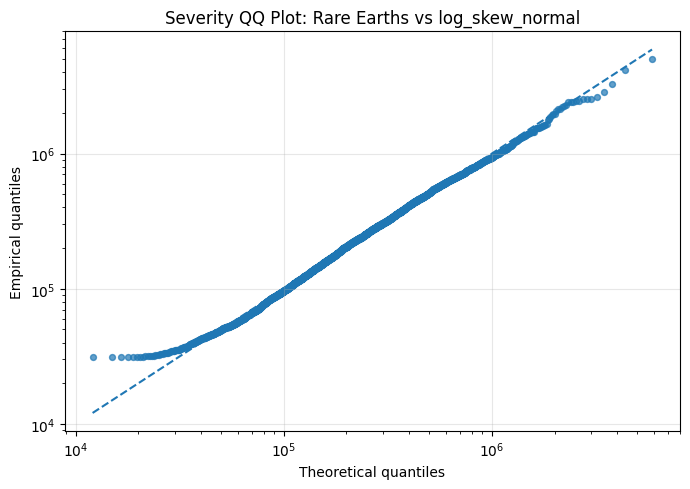

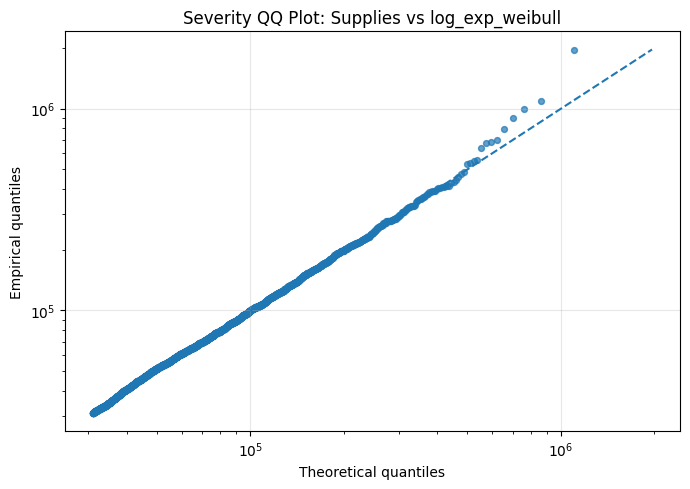

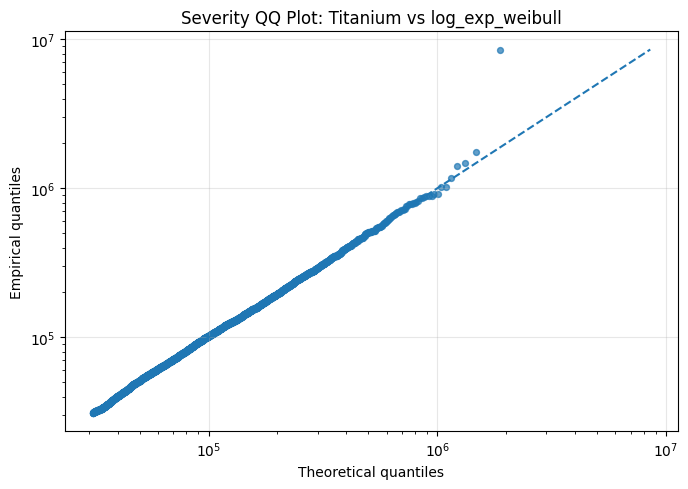

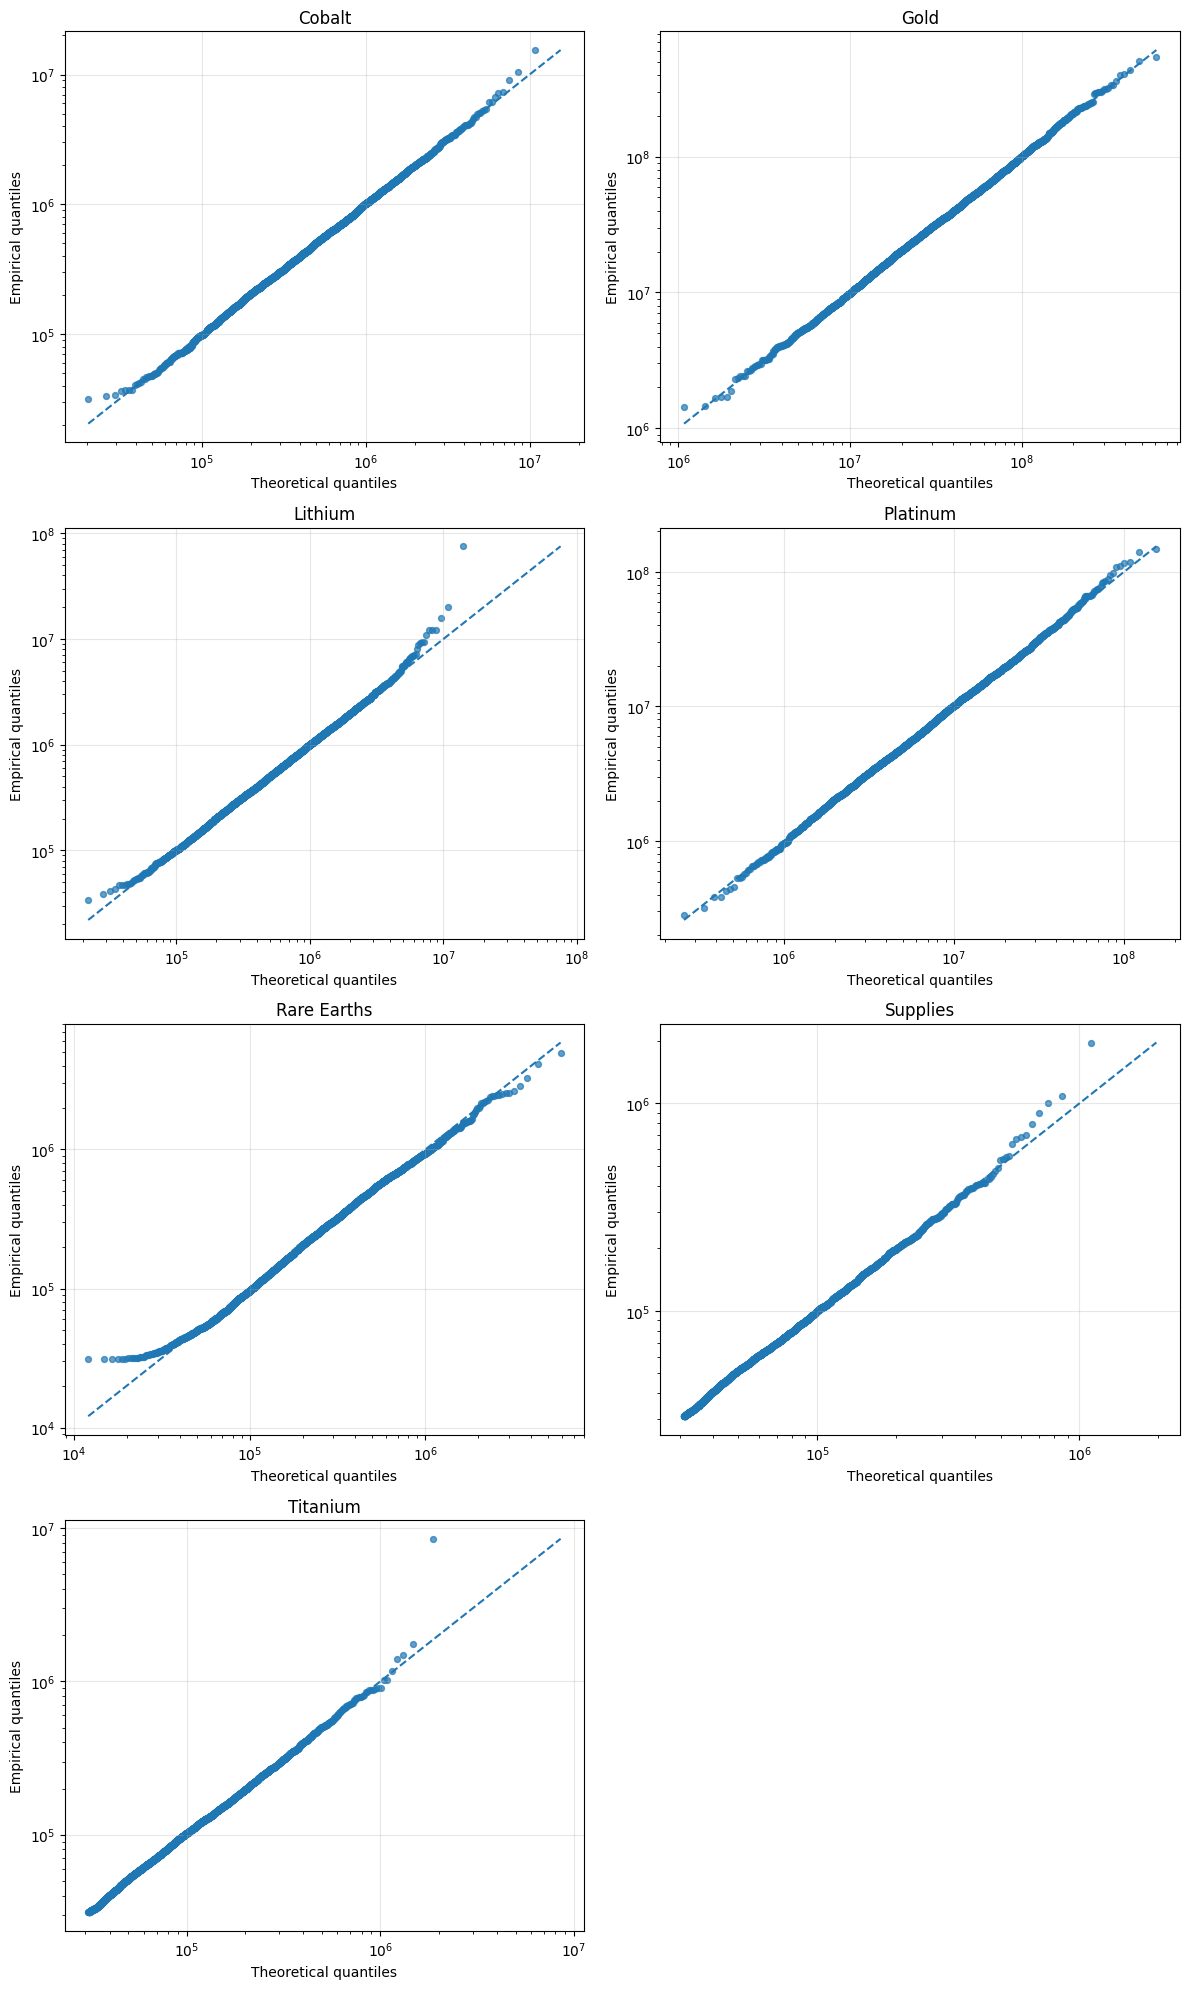


All severity QQ plots saved to: /Users/ben/Desktop/Uni/ACTL/ACTL4001/Assignment Code/Basic Data Cleaning and Modeling/qq_plots_severity_only


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import lognorm, skewnorm, exponweib

# ============================================================
# CONFIG
# ============================================================
CLEANED_FILE = Path(
    "/Users/ben/Desktop/Uni/ACTL/ACTL4001/Assignment Code/Basic Data Cleaning and Modeling/srcsc-2026-claims-cargo_cleaned.xlsx"
)

SEV_SHEET = "sev"
OUTPUT_DIR = Path("qq_plots_severity_only")
OUTPUT_DIR.mkdir(exist_ok=True)

USE_LOG_AXES_FOR_SEVERITY = True

# ============================================================
# FITTED SEVERITY DISTRIBUTIONS
# ============================================================
SEVERITY_SPECS = {
    "cobalt": {
        "dist": "lognormal",
        "mu": 13.061442337216045,
        "sigma": 0.8569081381822045,
    },
    "gold": {
        "dist": "log_skew_normal",
        "shape": -0.7985638313815884,
        "loc": 17.68816928480843,
        "scale": 0.987915167223077,
    },
    "lithium": {
        "dist": "lognormal",
        "mu": 13.226583575398298,
        "sigma": 0.8816801497124209,
    },
    "platinum": {
        "dist": "log_skew_normal",
        "shape": -0.7358336912820225,
        "loc": 16.24010114678375,
        "scale": 0.9828604406948547,
    },
    "rare earths": {
        "dist": "log_skew_normal",
        "shape": 1.1745797426685858,
        "loc": 11.565385848921597,
        "scale": 1.050387375627892,
    },
    "supplies": {
        "dist": "log_exp_weibull",
        "a": 0.5032574573,
        "c": 2.0603365462,
        "loc_log": 10.3422251856,
        "scale_log": 1.3075827421,
    },
    "titanium": {
        "dist": "log_exp_weibull",
        "a": 0.5305097331,
        "c": 2.4126125838,
        "loc_log": 10.3422162683,
        "scale_log": 1.7126950865,
    },
}

# ============================================================
# HELPERS
# ============================================================
def find_first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def normalise_cargo_label(x):
    x = str(x).strip().lower()
    replacements = {
        "rare earth": "rare earths",
        "rare-earth": "rare earths",
        "rare-earths": "rare earths",
        "rare_earth": "rare earths",
        "rare_earths": "rare earths",
    }
    return replacements.get(x, x)


def get_plotting_positions(n):
    return (np.arange(1, n + 1) - 0.5) / n


def severity_theoretical_quantiles(probs, spec):
    dist = spec["dist"]

    if dist == "lognormal":
        # X ~ Lognormal(mu, sigma)
        return lognorm.ppf(
            probs,
            s=spec["sigma"],
            scale=np.exp(spec["mu"])
        )

    elif dist == "log_skew_normal":
        # log(X) ~ SkewNormal(shape, loc, scale)
        return np.exp(
            skewnorm.ppf(
                probs,
                a=spec["shape"],
                loc=spec["loc"],
                scale=spec["scale"],
            )
        )

    elif dist == "log_exp_weibull":
        # log(X) ~ Exponentiated Weibull(a, c, loc_log, scale_log)
        return np.exp(
            exponweib.ppf(
                probs,
                a=spec["a"],
                c=spec["c"],
                loc=spec["loc_log"],
                scale=spec["scale_log"],
            )
        )

    else:
        raise ValueError(f"Unknown distribution: {dist}")


def qq_plot(ax, theoretical, observed, title, log_axes=False):
    theoretical = np.asarray(theoretical, dtype=float)
    observed = np.asarray(observed, dtype=float)

    mask = np.isfinite(theoretical) & np.isfinite(observed)
    theoretical = theoretical[mask]
    observed = observed[mask]

    ax.scatter(theoretical, observed, s=18, alpha=0.7)

    lo = min(np.min(theoretical), np.min(observed))
    hi = max(np.max(theoretical), np.max(observed))
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5)

    ax.set_title(title)
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Empirical quantiles")
    ax.grid(True, alpha=0.3)

    if log_axes and np.all(theoretical > 0) and np.all(observed > 0):
        ax.set_xscale("log")
        ax.set_yscale("log")


# ============================================================
# LOAD SEVERITY DATA
# ============================================================
sev_df = pd.read_excel(CLEANED_FILE, sheet_name=SEV_SHEET)
sev_df = sev_df.loc[:, ~sev_df.columns.duplicated()].copy()

cargo_candidates = ["cargo_type", "cargo", "cargo_category", "type_of_cargo"]
sev_candidates = ["claim_amount", "severity", "claim_size", "loss_amount", "paid_amount"]

sev_cargo_col = find_first_existing_column(sev_df, cargo_candidates)
sev_amount_col = find_first_existing_column(sev_df, sev_candidates)

if sev_cargo_col is None:
    raise ValueError(
        f"Could not find cargo column. Columns found: {list(sev_df.columns)}"
    )

if sev_amount_col is None:
    raise ValueError(
        f"Could not find severity amount column. Columns found: {list(sev_df.columns)}"
    )

sev_df[sev_cargo_col] = sev_df[sev_cargo_col].astype(str).map(normalise_cargo_label)
sev_df[sev_amount_col] = pd.to_numeric(sev_df[sev_amount_col], errors="coerce")

sev_df = sev_df.dropna(subset=[sev_cargo_col, sev_amount_col]).copy()
sev_df = sev_df[sev_df[sev_amount_col] > 0].copy()

print("Using cargo column:", sev_cargo_col)
print("Using severity column:", sev_amount_col)
print("Unique cargo types in data:", sorted(sev_df[sev_cargo_col].dropna().unique()))

# ============================================================
# INDIVIDUAL QQ PLOTS
# ============================================================
for cargo, spec in SEVERITY_SPECS.items():
    x = sev_df.loc[sev_df[sev_cargo_col] == cargo, sev_amount_col].to_numpy(dtype=float)
    x = np.sort(x[np.isfinite(x) & (x > 0)])

    if len(x) == 0:
        print(f"Skipping {cargo}: no positive observations found.")
        continue

    p = get_plotting_positions(len(x))
    theoretical = severity_theoretical_quantiles(p, spec)

    fig, ax = plt.subplots(figsize=(7, 5))
    qq_plot(
        ax=ax,
        theoretical=theoretical,
        observed=x,
        title=f"Severity QQ Plot: {cargo.title()} vs {spec['dist']}",
        log_axes=USE_LOG_AXES_FOR_SEVERITY,
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"qq_severity_{cargo.replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# ============================================================
# COMBINED PANEL
# ============================================================
cargo_list = list(SEVERITY_SPECS.keys())
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
axes = axes.flatten()

for i, cargo in enumerate(cargo_list):
    ax = axes[i]
    spec = SEVERITY_SPECS[cargo]

    x = sev_df.loc[sev_df[sev_cargo_col] == cargo, sev_amount_col].to_numpy(dtype=float)
    x = np.sort(x[np.isfinite(x) & (x > 0)])

    if len(x) == 0:
        ax.set_title(f"{cargo.title()} (no data)")
        ax.axis("off")
        continue

    p = get_plotting_positions(len(x))
    theoretical = severity_theoretical_quantiles(p, spec)

    qq_plot(
        ax=ax,
        theoretical=theoretical,
        observed=x,
        title=cargo.title(),
        log_axes=USE_LOG_AXES_FOR_SEVERITY,
    )

for j in range(len(cargo_list), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "qq_severity_all_cargo_types.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\nAll severity QQ plots saved to: {OUTPUT_DIR.resolve()}")

Selected model parameter estimations

In [8]:
# ============================================================
# SETTINGS
# ============================================================
BOOTSTRAP_ITERATIONS = 500
RANDOM_SEED = 42

# Assumes you already ran:
# freq_df, sev_df, meta = load_clean_data(CLEANED_FILE)

# ============================================================
# NEGATIVE BINOMIAL NB2
# Var(Y) = mu + alpha * mu^2
# ============================================================
def nb2_neg_loglik(params, y):
    log_mu, log_alpha = params
    mu = np.exp(log_mu)
    alpha = np.exp(log_alpha)

    if (not np.isfinite(mu)) or (not np.isfinite(alpha)) or (mu <= 0) or (alpha <= 0):
        return np.inf

    r = 1.0 / alpha
    p = r / (r + mu)

    return -np.sum(nbinom.logpmf(y, n=r, p=p))


def fit_nb2_params(y):
    y = np.asarray(y, dtype=float)

    y_mean = float(np.mean(y))
    y_var = float(np.var(y, ddof=1))
    alpha_start = max((y_var - y_mean) / max(y_mean ** 2, 1e-12), 1e-8)

    res = minimize(
        nb2_neg_loglik,
        x0=np.array([np.log(max(y_mean, 1e-8)), np.log(alpha_start)]),
        args=(y,),
        method="L-BFGS-B",
    )

    if not res.success:
        raise RuntimeError("NB fit failed")

    return {
        "mu": float(np.exp(res.x[0])),
        "alpha": float(np.exp(res.x[1])),
    }


# ============================================================
# SEVERITY PARAMETER FITS
# ============================================================
def fit_lognormal_params(x):
    x = np.asarray(x, dtype=float)
    logx = np.log(x)

    mu = float(np.mean(logx))
    sigma = float(np.std(logx, ddof=0))

    if sigma <= 0:
        raise RuntimeError("Invalid sigma")

    return {
        "mu": mu,
        "sigma": sigma,
    }


def fit_log_skew_normal_params(x):
    x = np.asarray(x, dtype=float)
    logx = np.log(x)

    shape, loc, scale = skewnorm.fit(logx)

    shape = float(shape)
    loc = float(loc)
    scale = float(scale)

    if scale <= 0:
        raise RuntimeError("Invalid scale")

    return {
        "shape": shape,
        "loc": loc,
        "scale": scale,
    }


def fit_log_exp_weibull_params(x):
    x = np.asarray(x, dtype=float)
    logx = np.log(x)

    a, c, loc, scale = exponweib.fit(logx)

    a = float(a)
    c = float(c)
    loc = float(loc)
    scale = float(scale)

    if scale <= 0:
        raise RuntimeError("Invalid scale")

    return {
        "a": a,
        "c": c,
        "loc_log": loc,
        "scale_log": scale,
    }


def fit_best_severity_model(x, model_name):
    if model_name == "lognormal":
        return fit_lognormal_params(x)
    elif model_name == "log_skew_normal":
        return fit_log_skew_normal_params(x)
    elif model_name == "log_exp_weibull":
        return fit_log_exp_weibull_params(x)
    else:
        raise ValueError(f"Unsupported model: {model_name}")


# ============================================================
# BOOTSTRAP FUNCTION
# ============================================================
def bootstrap_parameter_se(fit_func, data, n_boot=500, seed=42, min_success=100):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    n = len(data)

    estimates = []

    for _ in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)

        try:
            params = fit_func(sample)
            estimates.append(params)
        except Exception:
            continue

    if len(estimates) < min_success:
        raise RuntimeError(f"Too few successful bootstrap fits: {len(estimates)}")

    boot_df = pd.DataFrame(estimates)

    summary_rows = []
    for col in boot_df.columns:
        summary_rows.append({
            "parameter": col,
            "bootstrap_mean": boot_df[col].mean(),
            "std_error": boot_df[col].std(ddof=1),
            "ci_2.5%": boot_df[col].quantile(0.025),
            "ci_25%": boot_df[col].quantile(0.25),
            "ci_75%": boot_df[col].quantile(0.75),
            "ci_97.5%": boot_df[col].quantile(0.975),
            "n_success": len(boot_df),
        })

    summary_df = pd.DataFrame(summary_rows)
    return summary_df, boot_df


# ============================================================
# BEST MODELS FROM YOUR UPDATED TABLE
# ============================================================
BEST_SEV_MODELS = {
    "cobalt": "lognormal",
    "gold": "log_skew_normal",
    "lithium": "lognormal",
    "platinum": "log_skew_normal",
    "rare earths": "log_skew_normal",
    "supplies": "log_exp_weibull",
    "titanium": "log_exp_weibull",
}


# ============================================================
# 1) FREQUENCY PARAMETER STANDARD ERRORS
# ============================================================
freq_count_col = meta["freq_count_col"]
y_freq = freq_df[freq_count_col].to_numpy()

freq_point = fit_nb2_params(y_freq)

freq_se_summary, freq_boot = bootstrap_parameter_se(
    fit_func=fit_nb2_params,
    data=y_freq,
    n_boot=BOOTSTRAP_ITERATIONS,
    seed=RANDOM_SEED,
)

freq_point_df = pd.DataFrame({
    "parameter": list(freq_point.keys()),
    "point_estimate": list(freq_point.values()),
})

freq_final = freq_point_df.merge(freq_se_summary, on="parameter", how="left")

print("\n=== FREQUENCY PARAMETER STANDARD ERRORS ===")
print(freq_final.round(6))


# ============================================================
# 2) SEVERITY PARAMETER STANDARD ERRORS
# ============================================================
sev_cargo_col = meta["sev_cargo_col"]
sev_amount_col = meta["sev_amount_col"]

all_sev_results = []

for cargo, model_name in BEST_SEV_MODELS.items():
    x = sev_df.loc[sev_df[sev_cargo_col] == cargo, sev_amount_col].to_numpy(dtype=float)
    x = x[np.isfinite(x) & (x > 0)]

    if len(x) < 20:
        print(f"Skipping {cargo}: too few observations")
        continue

    point_est = fit_best_severity_model(x, model_name)

    se_summary, boot_df = bootstrap_parameter_se(
        fit_func=lambda sample, m=model_name: fit_best_severity_model(sample, m),
        data=x,
        n_boot=BOOTSTRAP_ITERATIONS,
        seed=RANDOM_SEED,
    )

    point_df = pd.DataFrame({
        "cargo_type": cargo,
        "distribution": model_name,
        "parameter": list(point_est.keys()),
        "point_estimate": list(point_est.values()),
    })

    merged = point_df.merge(se_summary, on="parameter", how="left")
    all_sev_results.append(merged)

sev_final = pd.concat(all_sev_results, ignore_index=True)

print("\n=== SEVERITY PARAMETER STANDARD ERRORS ===")
print(sev_final.round(6))


# ============================================================
# OPTIONAL: SAVE RESULTS
# ============================================================
output_path = CLEANED_FILE.parent / "parameter_standard_errors.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    freq_final.to_excel(writer, sheet_name="freq_param_se", index=False)
    sev_final.to_excel(writer, sheet_name="sev_param_se", index=False)

print("\nSaved to:", output_path)


=== FREQUENCY PARAMETER STANDARD ERRORS ===
  parameter  point_estimate  bootstrap_mean  std_error   ci_2.5%    ci_25%  \
0        mu        0.244779        0.244664   0.001715  0.241200  0.243564   
1     alpha        1.863151        1.868085   0.039580  1.791935  1.842235   

     ci_75%  ci_97.5%  n_success  
0  0.245791  0.248024        500  
1  1.893270  1.945818        500  


/Users/ben/Library/Python/3.9/lib/python/site-packages/scipy/stats/_continuous_distns.py:2065: RuntimeWarning: invalid value encountered in add
  logp = (np.log(a) + np.log(c) + sc.xlogy(a - 1.0, exm1c) +



=== SEVERITY PARAMETER STANDARD ERRORS ===
     cargo_type     distribution  parameter  point_estimate  bootstrap_mean  \
0        cobalt        lognormal         mu       13.061442       13.062396   
1        cobalt        lognormal      sigma        0.856908        0.856650   
2          gold  log_skew_normal      shape       -0.798564       -0.768073   
3          gold  log_skew_normal        loc       17.688169       17.664537   
4          gold  log_skew_normal      scale        0.987915        0.984146   
5       lithium        lognormal         mu       13.226584       13.226429   
6       lithium        lognormal      sigma        0.881680        0.882243   
7      platinum  log_skew_normal      shape       -0.735834       -0.660406   
8      platinum  log_skew_normal        loc       16.240101       16.188289   
9      platinum  log_skew_normal      scale        0.982860        0.978340   
10  rare earths  log_skew_normal      shape        1.174580        1.175610   
11  rare

Calculating Expected losses, STD, Premiums and reserves setting


=== BASE CASE REQUIRED INITIAL RESERVE ===
Required initial reserve = 16,131,181,640.62
Worst annual ruin probability at this reserve = 1.0000%
Final ruin-to-date probability over 10 years = 2.3000%

=== CONDENSED BASE CASE RESULTS ===
   year       expected_loss       std_dev_loss              var_95  \
0     1 21,156,024,593.4962 2,181,789,450.9869 24,909,557,167.9148   
1     2 22,060,209,087.4276 2,247,510,797.9002 25,727,535,185.9238   
2     3 23,179,834,555.0556 2,297,345,564.1556 27,001,855,135.0618   
3     4 24,263,498,079.4017 2,429,115,367.7376 28,506,945,632.9965   
4     5 25,438,147,433.5318 2,543,884,615.6527 29,649,854,839.2611   
5     6 26,636,345,110.4382 2,675,827,502.7911 31,065,044,590.3034   
6     7 27,853,992,886.2681 2,741,735,839.2811 32,377,955,423.8230   
7     8 29,162,893,132.9955 2,833,674,047.5135 34,001,979,691.5249   
8     9 30,458,142,130.6756 3,036,916,336.3736 35,476,231,019.5121   
9    10 31,817,712,127.7197 3,132,421,844.5605 37,080,830,993.6

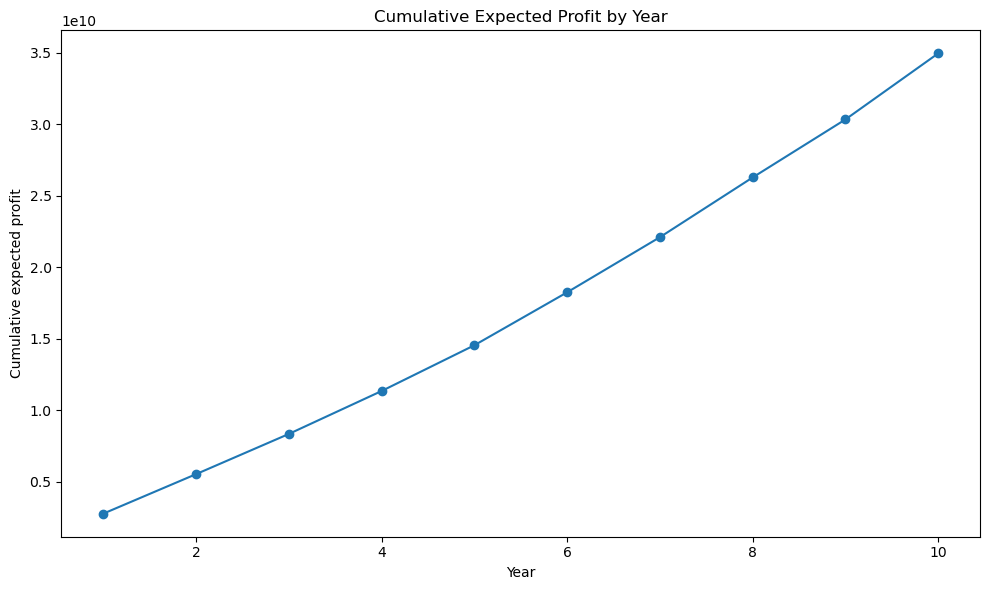

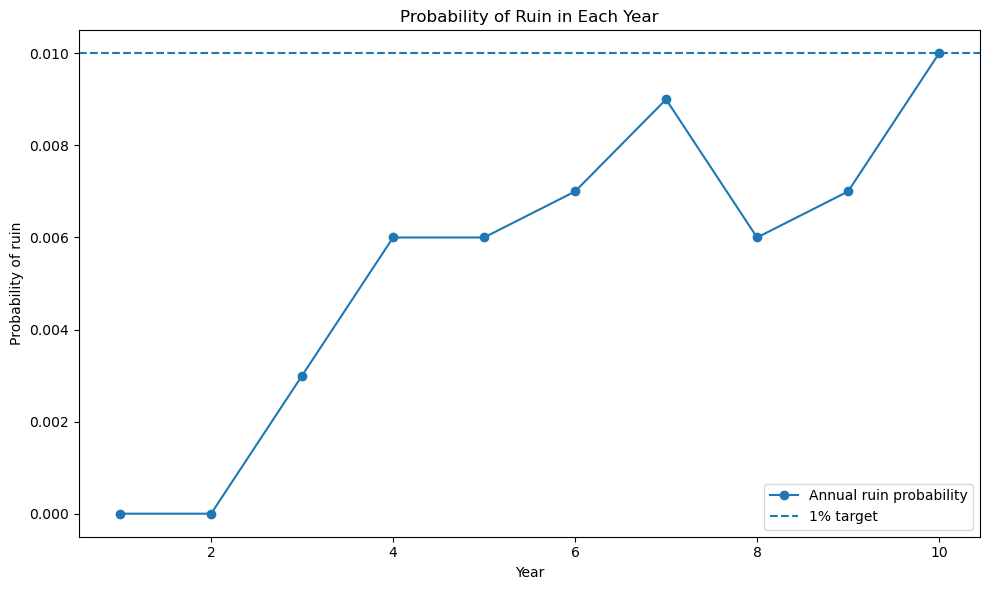

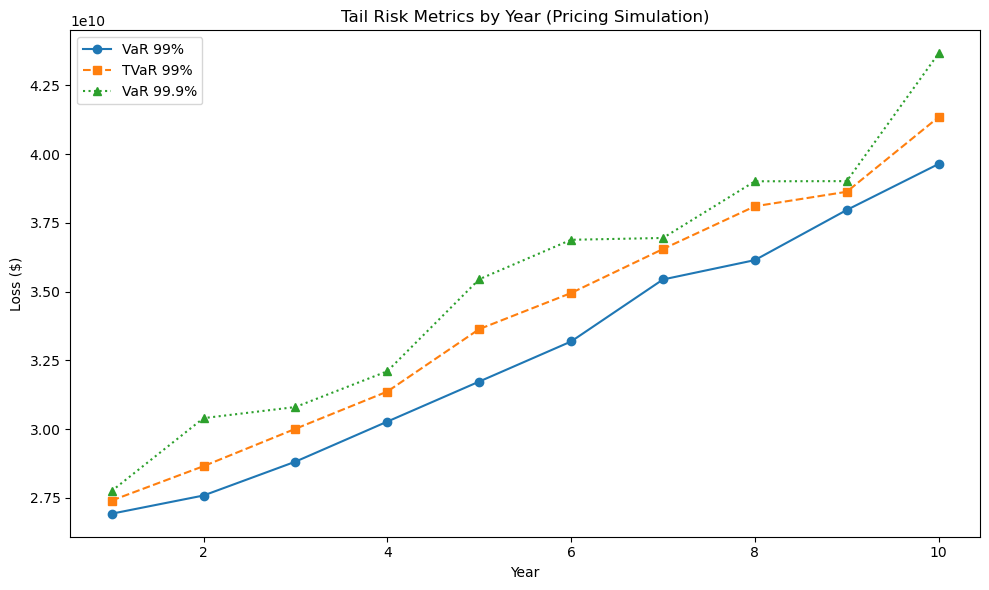

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# =========================================================
# USER INPUTS
# =========================================================
CARGO_VOLUME_INPUTS = {
    "titanium": {
        "annual_tons_mean": 286_350,
        "mean_weight_kg": 187_469.52,
    },
    "cobalt": {
        "annual_tons_mean": 228_000,
        "mean_weight_kg": 150_007.17,
    },
    "lithium": {
        "annual_tons_mean": 169_275,
        "mean_weight_kg": 112_027.95,
    },
    "rare earth": {
        "annual_tons_mean": 57_150,
        "mean_weight_kg": 37_688.51,
    },
    "gold": {
        "annual_tons_mean": 5_775,
        "mean_weight_kg": 3_810.13,
    },
    "platinum": {
        "annual_tons_mean": 3_450,
        "mean_weight_kg": 2_285.99,
    },
    "supplies": {
        "annual_tons_mean": 114_753,
        "mean_weight_kg": 75_189.57,
    },
}

# =========================================================
# MODELLING SETTINGS
# =========================================================
TONS_CV = 0.10

# Frequency model per shipment: NB2
FREQ_MU = 0.244779
FREQ_ALPHA = 1.863151

N_SIMS = 1_000
N_YEARS = 10
RANDOM_SEED = 42

# =========================================================
# PREMIUM SETTINGS
# premium = (EL + risk_loading * SD + expense_variable * EL) * (1 + profit_margin)
# =========================================================
RISK_LOADING = 0.2
EXPENSE_VARIABLE = 0.20
PROFIT_MARGIN = 0.12

# =========================================================
# STOCHASTIC 10-YEAR INTEREST RATE ASSUMPTION
# mean     = 2.8957%
# variance = 0.0122332%  (interpreted as percentage-point-squared)
# =========================================================
INTEREST_RATE_MEAN_PCT = 2.8957
INTEREST_RATE_VARIANCE_PCT2 = 0.0122332

INTEREST_RATE_MEAN = INTEREST_RATE_MEAN_PCT / 100.0
INTEREST_RATE_SD = np.sqrt(INTEREST_RATE_VARIANCE_PCT2) / 100.0

MIN_INTEREST_RATE = -0.95

# =========================================================
# BASE PRICES PER KG
# =========================================================
BASE_PRICES_PER_KG = {
    "titanium": 7.0,
    "supplies": 10.0,
    "cobalt": 52.0,
    "lithium": 82.0,
    "rare earth": 85.0,
    "gold": 54_500.0,
    "platinum": 135_600.0,
}

# =========================================================
# STOCHASTIC INFLATION ASSUMPTION
# =========================================================
INFLATION_MEAN_PCT = 2.46496
INFLATION_VARIANCE_PCT2 = 0.034085

INFLATION_MEAN = INFLATION_MEAN_PCT / 100.0
INFLATION_SD = np.sqrt(INFLATION_VARIANCE_PCT2) / 100.0

MIN_INFLATION_RATE = -0.95

# =========================================================
# CLUSTER / MINE GROWTH ASSUMPTIONS
# =========================================================
HELIONIS_BASE_PROD = 375.0
BAYESIA_BASE_PROD = 250.0
ORYN_BASE_PROD = 125.0

HELIONIS_MINES = 30
BAYESIA_MINES = 15
ORYN_MINES = 10

HELIONIS_MEAN_GROWTH = (1.25 ** (1.0 / 10.0)) - 1.0
BAYESIA_MEAN_GROWTH = (1.25 ** (1.0 / 10.0)) - 1.0
ORYN_MEAN_GROWTH = (1.15 ** (1.0 / 10.0)) - 1.0

PRODUCTION_GROWTH_SD_MULTIPLIER = 0.25

HELIONIS_GROWTH_SD = PRODUCTION_GROWTH_SD_MULTIPLIER * HELIONIS_MEAN_GROWTH
BAYESIA_GROWTH_SD = PRODUCTION_GROWTH_SD_MULTIPLIER * BAYESIA_MEAN_GROWTH
ORYN_GROWTH_SD = PRODUCTION_GROWTH_SD_MULTIPLIER * ORYN_MEAN_GROWTH

MIN_PRODUCTION_GROWTH_RATE = -0.95

# =========================================================
# SEVERITY DISTRIBUTIONS
# =========================================================
SEVERITY_MODELS = {
    "cobalt": {
        "dist": "lognormal",
        "mu": 13.061442337216045,
        "sigma": 0.8569081381822045,
    },
    "gold": {
        "dist": "logskewnorm",
        "shape": -0.7985638313815884,
        "loc": 17.68816928480843,
        "scale": 0.987915167223077,
    },
    "lithium": {
        "dist": "lognormal",
        "mu": 13.226583575398298,
        "sigma": 0.8816801497124209,
    },
    "platinum": {
        "dist": "logskewnorm",
        "shape": -0.7358336912820225,
        "loc": 16.24010114678375,
        "scale": 0.9828604406948547,
    },
    "rare earth": {
        "dist": "logskewnorm",
        "shape": 1.1745797426685858,
        "loc": 11.565385848921597,
        "scale": 1.050387375627892,
    },
    "supplies": {
        "dist": "logexpweibull",
        "a": 0.5032574573,
        "c": 2.0603365462,
        "loc_log": 10.3422251856,
        "scale_log": 1.3075827421,
    },
    "titanium": {
        "dist": "logexpweibull",
        "a": 0.5305097331,
        "c": 2.4126125838,
        "loc_log": 10.3422162683,
        "scale_log": 1.7126950865,
    },
}

# =========================================================
# EXPERIENCE TEST CASES
# Premiums charged remain fixed from the original pricing model.
# =========================================================
EXPERIENCE_CASES = {
    "Base Experience": {
        "inflation_mean_shift": 0.00,
        "inflation_sd_mult": 1.00,

        "production_mean_mult": 1.00,
        "production_sd_mult": 1.00,

        "tons_cv_mult": 1.00,

        "freq_level_mult": 1.00,
        "freq_shock_cv": 0.10,

        "alpha_level_mult": 1.00,
        "alpha_shock_cv": 0.15,

        "severity_level_mult": 1.00,
        "severity_shock_cv": 0.15,

        "expense_level_mult": 1.00,
        "expense_shock_cv": 0.05,

        "cargo_price_idio_cv": 0.05,
    },
}

# =========================================================
# FIXED INITIAL RESERVE MODEL
# We set ONE reserve at time 0 and do NOT reset it each year.
# Goal:
#   max_t P(ruin in year t) <= 1%
#
# Ruin in year t occurs if closing assets at the end of year t are below 0.
# =========================================================
TARGET_ANNUAL_RUIN_PROB = 0.01
RESERVE_SEARCH_TOLERANCE = 1_000_000.0
RESERVE_START_GUESS = 18_000_000_000.0
RESERVE_STEP_FRACTION = 0.10

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def nb2_to_scipy_params(mu, alpha):
    """
    NB2 parameterization:
        Var(N) = mu + alpha * mu^2

    SciPy mapping:
        n = 1 / alpha
        p = n / (n + mu)
    """
    n = 1.0 / alpha
    p = n / (n + mu)
    return n, p


def nb2_to_scipy_params_vector(mu, alpha):
    mu = np.maximum(mu, 1e-12)
    alpha = np.maximum(alpha, 1e-12)
    n = 1.0 / alpha
    p = n / (n + mu)
    return n, p


def lognormal_mean_one_factors(size, cv, rng):
    """
    Returns lognormal random factors with mean = 1 and a given coefficient of variation.
    """
    cv = max(float(cv), 0.0)
    if cv == 0.0:
        return np.ones(size)

    sigma2 = np.log(1.0 + cv**2)
    sigma = np.sqrt(sigma2)
    mu = -0.5 * sigma2
    return rng.lognormal(mean=mu, sigma=sigma, size=size)


def sample_base_severity(cargo_type, size, rng):
    params = SEVERITY_MODELS[cargo_type]
    dist_name = params["dist"]

    if dist_name == "lognormal":
        y = rng.normal(loc=params["mu"], scale=params["sigma"], size=size)
        return np.exp(y)

    if dist_name == "logskewnorm":
        y = stats.skewnorm.rvs(
            a=params["shape"],
            loc=params["loc"],
            scale=params["scale"],
            size=size,
            random_state=rng,
        )
        return np.exp(y)

    if dist_name == "logexpweibull":
        y = stats.exponweib.rvs(
            a=params["a"],
            c=params["c"],
            loc=params["loc_log"],
            scale=params["scale_log"],
            size=size,
            random_state=rng,
        )
        return np.exp(y)

    raise ValueError(f"Unknown severity distribution for {cargo_type}: {dist_name}")


def calculate_premium(expected_loss, std_loss, risk_loading, expense_variable, profit_margin):
    base_cost = expected_loss + risk_loading * std_loss + expense_variable * expected_loss
    return base_cost * (1.0 + profit_margin)


def tail_mean(x, q):
    threshold = np.quantile(x, q)
    tail = x[x >= threshold]
    if len(tail) == 0:
        return np.nan
    return tail.mean()


def simulate_inflation_paths(n_sims, n_years, mean_rate, sd_rate, rng, min_rate=-0.95):
    inflation_rates = rng.normal(loc=mean_rate, scale=sd_rate, size=(n_sims, n_years))
    inflation_rates = np.clip(inflation_rates, min_rate, None)
    price_multipliers = np.cumprod(1.0 + inflation_rates, axis=1)
    return inflation_rates, price_multipliers


def simulate_interest_rate_paths(n_sims, n_years, mean_rate, sd_rate, rng, min_rate=-0.95):
    rates = rng.normal(loc=mean_rate, scale=sd_rate, size=(n_sims, n_years))
    rates = np.clip(rates, min_rate, None)
    return rates


def simulate_cluster_production_paths(
    n_sims,
    n_years,
    rng,
    helionis_mines,
    bayesia_mines,
    oryn_mines,
    helionis_base_prod,
    bayesia_base_prod,
    oryn_base_prod,
    helionis_mean_growth,
    helionis_growth_sd,
    bayesia_mean_growth,
    bayesia_growth_sd,
    oryn_mean_growth,
    oryn_growth_sd,
    min_growth_rate=-0.95,
):
    helionis_growth = rng.normal(
        loc=helionis_mean_growth,
        scale=helionis_growth_sd,
        size=(n_sims, n_years),
    )
    bayesia_growth = rng.normal(
        loc=bayesia_mean_growth,
        scale=bayesia_growth_sd,
        size=(n_sims, n_years),
    )
    oryn_growth = rng.normal(
        loc=oryn_mean_growth,
        scale=oryn_growth_sd,
        size=(n_sims, n_years),
    )

    helionis_growth = np.clip(helionis_growth, min_growth_rate, None)
    bayesia_growth = np.clip(bayesia_growth, min_growth_rate, None)
    oryn_growth = np.clip(oryn_growth, min_growth_rate, None)

    helionis_prod_per_mine = helionis_base_prod * np.cumprod(1.0 + helionis_growth, axis=1)
    bayesia_prod_per_mine = bayesia_base_prod * np.cumprod(1.0 + bayesia_growth, axis=1)
    oryn_prod_per_mine = oryn_base_prod * np.cumprod(1.0 + oryn_growth, axis=1)

    total_company_prod = (
        helionis_mines * helionis_prod_per_mine
        + bayesia_mines * bayesia_prod_per_mine
        + oryn_mines * oryn_prod_per_mine
    )

    base_total_company_prod = (
        helionis_mines * helionis_base_prod
        + bayesia_mines * bayesia_base_prod
        + oryn_mines * oryn_base_prod
    )

    company_production_multiplier = total_company_prod / base_total_company_prod

    summary = {
        "hel_prod": helionis_mines * helionis_prod_per_mine,
        "bay_prod": bayesia_mines * bayesia_prod_per_mine,
        "ory_prod": oryn_mines * oryn_prod_per_mine,
        "total_prod": total_company_prod,
        "hel_growth": helionis_growth,
        "bay_growth": bayesia_growth,
        "ory_growth": oryn_growth,
    }
    return company_production_multiplier, summary


def simulate_annual_tons_for_year(base_volume_inputs, company_production_multiplier, tons_cv, rng):
    n_sims = len(company_production_multiplier)
    simulated = {}

    for cargo_type, vals in base_volume_inputs.items():
        mean_tons = vals["annual_tons_mean"] * company_production_multiplier

        if tons_cv > 0:
            sigma2 = np.log(1.0 + tons_cv**2)
            sigma = np.sqrt(sigma2)
            mu = np.log(np.maximum(mean_tons, 1e-9)) - 0.5 * sigma2
            tons = rng.lognormal(mean=mu, sigma=sigma, size=n_sims)
        else:
            tons = mean_tons.copy()

        simulated[cargo_type] = tons

    return simulated


def build_year_prices_per_kg(base_prices_per_kg, price_multiplier_vector):
    year_prices = {}
    for cargo_type, base_price in base_prices_per_kg.items():
        year_prices[cargo_type] = base_price * price_multiplier_vector
    return year_prices


def build_year_price_draws_with_idiosyncratic_shocks(
    base_prices_per_kg,
    common_price_multiplier_vector,
    cargo_price_idio_cv,
    rng,
):
    n_sims = len(common_price_multiplier_vector)
    year_prices = {}

    for cargo_type, base_price in base_prices_per_kg.items():
        idio_factor = lognormal_mean_one_factors(
            size=n_sims,
            cv=cargo_price_idio_cv,
            rng=rng,
        )
        year_prices[cargo_type] = base_price * common_price_multiplier_vector * idio_factor

    return year_prices


def compute_year_price_summary(year, year_prices_per_kg):
    rows = []
    for cargo_type, prices in year_prices_per_kg.items():
        rows.append(
            {
                "year": year,
                "cargo_type": cargo_type,
                "mean_price_per_kg": prices.mean(),
                "std_price_per_kg": prices.std(ddof=1),
                "min_price_per_kg": prices.min(),
                "max_price_per_kg": prices.max(),
            }
        )
    return pd.DataFrame(rows)


def compute_year_revenue_summary(year, simulated_tons, year_prices_per_kg):
    rows = []

    for cargo_type in simulated_tons.keys():
        revenue = simulated_tons[cargo_type] * 1000.0 * year_prices_per_kg[cargo_type]
        rows.append(
            {
                "year": year,
                "cargo_type": cargo_type,
                "mean_revenue": revenue.mean(),
                "std_revenue": revenue.std(ddof=1),
                "min_revenue": revenue.min(),
                "max_revenue": revenue.max(),
            }
        )

    revenue_df = pd.DataFrame(rows)

    ores_only = revenue_df[revenue_df["cargo_type"] != "supplies"]
    total_expected_revenue_ores_only = ores_only["mean_revenue"].sum()
    total_expected_revenue_including_supplies = revenue_df["mean_revenue"].sum()

    total_summary = pd.DataFrame(
        {
            "year": [year],
            "total_expected_revenue_ores_only": [total_expected_revenue_ores_only],
            "total_expected_revenue_including_supplies": [total_expected_revenue_including_supplies],
        }
    )

    return revenue_df, total_summary


def sample_price_scaled_severity(
    cargo_type,
    size,
    rng,
    base_prices_per_kg,
    year_prices_per_kg,
    sim_index,
):
    base_claim_sizes = sample_base_severity(cargo_type=cargo_type, size=size, rng=rng)
    base_price = base_prices_per_kg[cargo_type]
    year_prices_for_claims = year_prices_per_kg[cargo_type][sim_index]
    price_ratio = year_prices_for_claims / base_price
    return base_claim_sizes * price_ratio


def run_one_year_simulation(
    year,
    base_volume_inputs,
    base_prices_per_kg,
    company_production_multiplier,
    price_multiplier_vector,
    tons_cv,
    freq_mu,
    freq_alpha,
    risk_loading,
    expense_variable,
    profit_margin,
    rng,
):
    n_sims = len(company_production_multiplier)

    simulated_tons = simulate_annual_tons_for_year(
        base_volume_inputs=base_volume_inputs,
        company_production_multiplier=company_production_multiplier,
        tons_cv=tons_cv,
        rng=rng,
    )

    year_prices_per_kg = build_year_prices_per_kg(
        base_prices_per_kg=base_prices_per_kg,
        price_multiplier_vector=price_multiplier_vector,
    )

    portfolio_losses = np.zeros(n_sims)
    shipment_summary_rows = []

    n_ship, p_ship = nb2_to_scipy_params(freq_mu, freq_alpha)

    for cargo_type, vals in base_volume_inputs.items():
        mean_weight_kg = vals["mean_weight_kg"]
        annual_tons = simulated_tons[cargo_type]

        estimated_shipments = annual_tons * 1000.0 / mean_weight_kg
        estimated_shipments_int = np.maximum(np.round(estimated_shipments).astype(int), 0)

        shipment_summary_rows.append(
            {
                "year": year,
                "cargo_type": cargo_type,
                "mean_annual_tons": annual_tons.mean(),
                "std_annual_tons": annual_tons.std(ddof=1),
                "mean_shipments": estimated_shipments.mean(),
                "std_shipments": estimated_shipments.std(ddof=1),
            }
        )

        losses = np.zeros(n_sims)

        annual_claim_counts = stats.nbinom.rvs(
            n=n_ship,
            p=p_ship,
            size=estimated_shipments_int.sum(),
            random_state=rng,
        )

        shipment_sim_index = np.repeat(np.arange(n_sims), estimated_shipments_int)
        shipment_claim_indicator = annual_claim_counts > 0

        if shipment_claim_indicator.any():
            positive_claim_counts = annual_claim_counts[shipment_claim_indicator]
            sim_index = np.repeat(
                shipment_sim_index[shipment_claim_indicator],
                positive_claim_counts,
            )
            total_claims = int(positive_claim_counts.sum())

            claim_sizes = sample_price_scaled_severity(
                cargo_type=cargo_type,
                size=total_claims,
                rng=rng,
                base_prices_per_kg=base_prices_per_kg,
                year_prices_per_kg=year_prices_per_kg,
                sim_index=sim_index,
            )

            losses = np.bincount(
                sim_index,
                weights=claim_sizes,
                minlength=n_sims,
            ).astype(float)

        portfolio_losses += losses

    expected_loss = portfolio_losses.mean()
    std_dev = portfolio_losses.std(ddof=1)

    var_95  = np.quantile(portfolio_losses, 0.95)
    var_99  = np.quantile(portfolio_losses, 0.99)
    var_999 = np.quantile(portfolio_losses, 0.999)
    tvar_99 = tail_mean(portfolio_losses, 0.99)      # TVaR 99%

    premium = calculate_premium(
        expected_loss=expected_loss,
        std_loss=std_dev,
        risk_loading=risk_loading,
        expense_variable=expense_variable,
        profit_margin=profit_margin,
    )

    shipment_summary_df = pd.DataFrame(shipment_summary_rows).sort_values("cargo_type").reset_index(drop=True)

    price_summary_df = compute_year_price_summary(
        year=year,
        year_prices_per_kg=year_prices_per_kg,
    )

    revenue_df, total_revenue_summary_df = compute_year_revenue_summary(
        year=year,
        simulated_tons=simulated_tons,
        year_prices_per_kg=year_prices_per_kg,
    )

    summary = {
        "year": year,
        "mean_production_multiplier": company_production_multiplier.mean(),
        "std_production_multiplier": company_production_multiplier.std(ddof=1),
        "mean_price_multiplier": price_multiplier_vector.mean(),
        "std_price_multiplier": price_multiplier_vector.std(ddof=1),
        "expected_loss": expected_loss,
        "std_dev": std_dev,
        "var_95": var_95,
        "var_99": var_99,
        "var_999": var_999,
        "tvar_99": tvar_99,                          # TVaR 99%
        "premium": premium,
        "total_expected_revenue_including_supplies":
            total_revenue_summary_df.loc[0, "total_expected_revenue_including_supplies"],
        "total_expected_revenue_ores_only":
            total_revenue_summary_df.loc[0, "total_expected_revenue_ores_only"],
    }

    return shipment_summary_df, price_summary_df, revenue_df, summary


def project_10_year_premiums(
    base_volume_inputs,
    base_prices_per_kg,
    tons_cv,
    freq_mu,
    freq_alpha,
    n_sims,
    n_years,
    seed,
    risk_loading,
    expense_variable,
    profit_margin,
):
    rng = np.random.default_rng(seed)

    inflation_rates, price_multipliers = simulate_inflation_paths(
        n_sims=n_sims,
        n_years=n_years,
        mean_rate=INFLATION_MEAN,
        sd_rate=INFLATION_SD,
        rng=rng,
        min_rate=MIN_INFLATION_RATE,
    )

    company_prod_multipliers, growth_summary = simulate_cluster_production_paths(
        n_sims=n_sims,
        n_years=n_years,
        rng=rng,
        helionis_mines=HELIONIS_MINES,
        bayesia_mines=BAYESIA_MINES,
        oryn_mines=ORYN_MINES,
        helionis_base_prod=HELIONIS_BASE_PROD,
        bayesia_base_prod=BAYESIA_BASE_PROD,
        oryn_base_prod=ORYN_BASE_PROD,
        helionis_mean_growth=HELIONIS_MEAN_GROWTH,
        helionis_growth_sd=HELIONIS_GROWTH_SD,
        bayesia_mean_growth=BAYESIA_MEAN_GROWTH,
        bayesia_growth_sd=BAYESIA_GROWTH_SD,
        oryn_mean_growth=ORYN_MEAN_GROWTH,
        oryn_growth_sd=ORYN_GROWTH_SD,
        min_growth_rate=MIN_PRODUCTION_GROWTH_RATE,
    )

    all_year_summaries = []
    all_shipment_summaries = []
    all_price_summaries = []
    all_revenue_summaries = []

    for year in range(1, n_years + 1):
        year_idx = year - 1

        company_multiplier = company_prod_multipliers[:, year_idx]
        price_multiplier = price_multipliers[:, year_idx]

        shipment_summary_df, price_summary_df, revenue_df, summary = run_one_year_simulation(
            year=year,
            base_volume_inputs=base_volume_inputs,
            base_prices_per_kg=base_prices_per_kg,
            company_production_multiplier=company_multiplier,
            price_multiplier_vector=price_multiplier,
            tons_cv=tons_cv,
            freq_mu=freq_mu,
            freq_alpha=freq_alpha,
            risk_loading=risk_loading,
            expense_variable=expense_variable,
            profit_margin=profit_margin,
            rng=rng,
        )

        summary["mean_inflation_rate"] = inflation_rates[:, year_idx].mean()
        summary["std_inflation_rate"] = inflation_rates[:, year_idx].std(ddof=1)

        summary["mean_helionis_production"] = growth_summary["hel_prod"][:, year_idx].mean()
        summary["std_helionis_production"] = growth_summary["hel_prod"][:, year_idx].std(ddof=1)

        summary["mean_bayesia_production"] = growth_summary["bay_prod"][:, year_idx].mean()
        summary["std_bayesia_production"] = growth_summary["bay_prod"][:, year_idx].std(ddof=1)

        summary["mean_oryn_production"] = growth_summary["ory_prod"][:, year_idx].mean()
        summary["std_oryn_production"] = growth_summary["ory_prod"][:, year_idx].std(ddof=1)

        summary["mean_total_company_production"] = growth_summary["total_prod"][:, year_idx].mean()
        summary["std_total_company_production"] = growth_summary["total_prod"][:, year_idx].std(ddof=1)

        all_year_summaries.append(summary)
        all_shipment_summaries.append(shipment_summary_df)
        all_price_summaries.append(price_summary_df)
        all_revenue_summaries.append(revenue_df)

    premium_projection_df = pd.DataFrame(all_year_summaries)
    shipment_projection_df = pd.concat(all_shipment_summaries, ignore_index=True)
    price_projection_df = pd.concat(all_price_summaries, ignore_index=True)
    revenue_projection_df = pd.concat(all_revenue_summaries, ignore_index=True)

    premium_projection_df["premium_growth_yoy"] = premium_projection_df["premium"].pct_change()
    premium_projection_df["cumulative_premium"] = premium_projection_df["premium"].cumsum()

    return (
        premium_projection_df,
        shipment_projection_df,
        price_projection_df,
        revenue_projection_df,
        inflation_rates,
        price_multipliers,
        company_prod_multipliers,
        growth_summary,
    )


# =========================================================
# STOCHASTIC ACTUAL LOSS MODEL FOR BALANCE SHEET TEST
# =========================================================
def simulate_actual_losses_one_year_stochastic(
    base_volume_inputs,
    base_prices_per_kg,
    company_production_multiplier,
    common_price_multiplier_vector,
    tons_cv,
    mu_ship_vector,
    alpha_ship_vector,
    severity_factor_vector,
    cargo_price_idio_cv,
    rng,
):
    n_sims = len(company_production_multiplier)

    simulated_tons = simulate_annual_tons_for_year(
        base_volume_inputs=base_volume_inputs,
        company_production_multiplier=company_production_multiplier,
        tons_cv=tons_cv,
        rng=rng,
    )

    year_prices_per_kg = build_year_price_draws_with_idiosyncratic_shocks(
        base_prices_per_kg=base_prices_per_kg,
        common_price_multiplier_vector=common_price_multiplier_vector,
        cargo_price_idio_cv=cargo_price_idio_cv,
        rng=rng,
    )

    n_ship_vector, p_ship_vector = nb2_to_scipy_params_vector(
        mu=mu_ship_vector,
        alpha=alpha_ship_vector,
    )

    portfolio_losses = np.zeros(n_sims)

    for cargo_type, vals in base_volume_inputs.items():
        mean_weight_kg = vals["mean_weight_kg"]
        annual_tons = simulated_tons[cargo_type]
        estimated_shipments = annual_tons * 1000.0 / mean_weight_kg
        estimated_shipments_int = np.maximum(np.round(estimated_shipments).astype(int), 0)

        total_shipments = estimated_shipments_int.sum()
        if total_shipments == 0:
            continue

        annual_claim_counts = stats.nbinom.rvs(
            n=np.repeat(n_ship_vector, estimated_shipments_int),
            p=np.repeat(p_ship_vector, estimated_shipments_int),
            size=total_shipments,
            random_state=rng,
        )

        shipment_sim_index = np.repeat(np.arange(n_sims), estimated_shipments_int)
        shipment_claim_indicator = annual_claim_counts > 0

        if not shipment_claim_indicator.any():
            continue

        positive_claim_counts = annual_claim_counts[shipment_claim_indicator]
        sim_index = np.repeat(
            shipment_sim_index[shipment_claim_indicator],
            positive_claim_counts,
        )
        total_claims = int(positive_claim_counts.sum())

        base_claim_sizes = sample_price_scaled_severity(
            cargo_type=cargo_type,
            size=total_claims,
            rng=rng,
            base_prices_per_kg=base_prices_per_kg,
            year_prices_per_kg=year_prices_per_kg,
            sim_index=sim_index,
        )

        claim_sizes = base_claim_sizes * severity_factor_vector[sim_index]

        losses = np.bincount(
            sim_index,
            weights=claim_sizes,
            minlength=n_sims,
        ).astype(float)

        portfolio_losses += losses

    return portfolio_losses


def simulate_balance_sheet_paths_with_fixed_initial_reserve(
    case_name,
    case_settings,
    pricing_projection_df,
    n_sims,
    n_years,
    seed,
    initial_reserve,
):
    rng = np.random.default_rng(seed)

    inflation_rates, price_multipliers = simulate_inflation_paths(
        n_sims=n_sims,
        n_years=n_years,
        mean_rate=INFLATION_MEAN + case_settings["inflation_mean_shift"],
        sd_rate=INFLATION_SD * case_settings["inflation_sd_mult"],
        rng=rng,
        min_rate=MIN_INFLATION_RATE,
    )

    company_prod_multipliers, growth_summary = simulate_cluster_production_paths(
        n_sims=n_sims,
        n_years=n_years,
        rng=rng,
        helionis_mines=HELIONIS_MINES,
        bayesia_mines=BAYESIA_MINES,
        oryn_mines=ORYN_MINES,
        helionis_base_prod=HELIONIS_BASE_PROD,
        bayesia_base_prod=BAYESIA_BASE_PROD,
        oryn_base_prod=ORYN_BASE_PROD,
        helionis_mean_growth=HELIONIS_MEAN_GROWTH * case_settings["production_mean_mult"],
        helionis_growth_sd=HELIONIS_GROWTH_SD * case_settings["production_sd_mult"],
        bayesia_mean_growth=BAYESIA_MEAN_GROWTH * case_settings["production_mean_mult"],
        bayesia_growth_sd=BAYESIA_GROWTH_SD * case_settings["production_sd_mult"],
        oryn_mean_growth=ORYN_MEAN_GROWTH * case_settings["production_mean_mult"],
        oryn_growth_sd=ORYN_GROWTH_SD * case_settings["production_sd_mult"],
        min_growth_rate=MIN_PRODUCTION_GROWTH_RATE,
    )

    interest_rates = simulate_interest_rate_paths(
        n_sims=n_sims,
        n_years=n_years,
        mean_rate=INTEREST_RATE_MEAN,
        sd_rate=INTEREST_RATE_SD,
        rng=rng,
        min_rate=MIN_INTEREST_RATE,
    )

    opening_assets = np.full(n_sims, float(initial_reserve))
    ever_ruined = np.zeros(n_sims, dtype=bool)
    rows = []

    for year in range(1, n_years + 1):
        year_idx = year - 1
        pricing_row = pricing_projection_df.loc[pricing_projection_df["year"] == year].iloc[0]

        premium_collected = pricing_row["premium"]

        company_multiplier = company_prod_multipliers[:, year_idx]
        common_price_multiplier_vector = price_multipliers[:, year_idx]

        tons_cv = TONS_CV * case_settings["tons_cv_mult"]

        freq_shock = lognormal_mean_one_factors(
            size=n_sims,
            cv=case_settings["freq_shock_cv"],
            rng=rng,
        )
        mu_ship_vector = FREQ_MU * case_settings["freq_level_mult"] * freq_shock

        alpha_shock = lognormal_mean_one_factors(
            size=n_sims,
            cv=case_settings["alpha_shock_cv"],
            rng=rng,
        )
        alpha_ship_vector = FREQ_ALPHA * case_settings["alpha_level_mult"] * alpha_shock

        severity_shock = lognormal_mean_one_factors(
            size=n_sims,
            cv=case_settings["severity_shock_cv"],
            rng=rng,
        )
        severity_factor_vector = case_settings["severity_level_mult"] * severity_shock

        expense_shock = lognormal_mean_one_factors(
            size=n_sims,
            cv=case_settings["expense_shock_cv"],
            rng=rng,
        )
        expense_ratio_vector = EXPENSE_VARIABLE * case_settings["expense_level_mult"] * expense_shock

        actual_losses = simulate_actual_losses_one_year_stochastic(
            base_volume_inputs=CARGO_VOLUME_INPUTS,
            base_prices_per_kg=BASE_PRICES_PER_KG,
            company_production_multiplier=company_multiplier,
            common_price_multiplier_vector=common_price_multiplier_vector,
            tons_cv=tons_cv,
            mu_ship_vector=mu_ship_vector,
            alpha_ship_vector=alpha_ship_vector,
            severity_factor_vector=severity_factor_vector,
            cargo_price_idio_cv=case_settings["cargo_price_idio_cv"],
            rng=rng,
        )

        underwriting_expense_vector = premium_collected * expense_ratio_vector

        underwriting_profit_vector = (
            premium_collected
            - actual_losses
            - underwriting_expense_vector
        )

        investment_income_vector = opening_assets * interest_rates[:, year_idx]
        total_profit_vector = underwriting_profit_vector + investment_income_vector
        closing_assets = opening_assets + total_profit_vector

        ruined_this_year = closing_assets < 0.0
        ever_ruined = ever_ruined | ruined_this_year

        shortfall_vector = np.maximum(-closing_assets, 0.0)

        combined_ratio_vector = (
            actual_losses
            + underwriting_expense_vector
        ) / premium_collected

        row = {
            "case": case_name,
            "year": year,
            "initial_reserve": float(initial_reserve),
            "premium_collected": premium_collected,
            "mean_opening_assets": opening_assets.mean(),
            "mean_interest_rate": interest_rates[:, year_idx].mean(),
            "sd_interest_rate": interest_rates[:, year_idx].std(ddof=1),
            "mean_investment_income": investment_income_vector.mean(),
            "mean_underwriting_expense": underwriting_expense_vector.mean(),
            "mean_actual_loss": actual_losses.mean(),
            "sd_actual_loss": actual_losses.std(ddof=1),
            "var95_loss": np.quantile(actual_losses, 0.95),
            "var99_loss": np.quantile(actual_losses, 0.99),
            "var999_loss": np.quantile(actual_losses, 0.999),
            "cte95_loss": tail_mean(actual_losses, 0.95),
            "cte99_loss": tail_mean(actual_losses, 0.99),
            "mean_underwriting_profit": underwriting_profit_vector.mean(),
            "mean_total_profit": total_profit_vector.mean(),
            "p01_total_profit": np.quantile(total_profit_vector, 0.01),
            "p05_total_profit": np.quantile(total_profit_vector, 0.05),
            "mean_closing_assets": closing_assets.mean(),
            "p01_closing_assets": np.quantile(closing_assets, 0.01),
            "p05_closing_assets": np.quantile(closing_assets, 0.05),
            "prob_underwriting_loss": np.mean(underwriting_profit_vector < 0.0),
            "prob_total_loss": np.mean(total_profit_vector < 0.0),
            "prob_ruin_in_year": np.mean(ruined_this_year),
            "prob_ruin_to_date": np.mean(ever_ruined),
            "mean_shortfall": shortfall_vector.mean(),
            "conditional_mean_shortfall": (
                shortfall_vector[shortfall_vector > 0.0].mean()
                if np.any(shortfall_vector > 0.0) else 0.0
            ),
            "mean_combined_ratio": combined_ratio_vector.mean(),
            "p95_combined_ratio": np.quantile(combined_ratio_vector, 0.95),
            "mean_inflation_rate": inflation_rates[:, year_idx].mean(),
            "sd_inflation_rate": inflation_rates[:, year_idx].std(ddof=1),
            "mean_total_company_production": growth_summary["total_prod"][:, year_idx].mean(),
            "sd_total_company_production": growth_summary["total_prod"][:, year_idx].std(ddof=1),
        }

        rows.append(row)
        opening_assets = closing_assets.copy()

    result_df = pd.DataFrame(rows)
    worst_annual_ruin_prob = float(result_df["prob_ruin_in_year"].max())

    return result_df, worst_annual_ruin_prob


def find_required_initial_reserve(
    case_name,
    case_settings,
    pricing_projection_df,
    n_sims,
    n_years,
    seed,
    target_annual_ruin_prob=0.01,
    tolerance=1_000_000.0,
    start_guess=20_000_000_000.0,
    step_fraction=0.10,
    max_iter=60,
):
    """
    Find the LOWEST initial reserve such that:

        max over years of P(ruin in year t) <= target_annual_ruin_prob

    The search starts around start_guess to reduce runtime.
    """
    cache = {}

    def evaluate(reserve):
        reserve = float(max(0.0, reserve))
        key = round(reserve, 2)

        if key not in cache:
            result_df, worst_annual_ruin_prob = simulate_balance_sheet_paths_with_fixed_initial_reserve(
                case_name=case_name,
                case_settings=case_settings,
                pricing_projection_df=pricing_projection_df,
                n_sims=n_sims,
                n_years=n_years,
                seed=seed,
                initial_reserve=reserve,
            )

            final_ruin_to_date = float(result_df["prob_ruin_to_date"].iloc[-1])

            cache[key] = {
                "reserve": reserve,
                "result_df": result_df,
                "worst_annual_ruin_prob": float(worst_annual_ruin_prob),
                "final_ruin_to_date": final_ruin_to_date,
            }

        return cache[key]

    guess = float(start_guess)
    guess_eval = evaluate(guess)

    # Step 1: bracket the solution around the starting guess
    if guess_eval["worst_annual_ruin_prob"] <= target_annual_ruin_prob:
        high = guess
        low = max(0.0, guess * (1.0 - step_fraction))
        low_eval = evaluate(low)

        while low > 0.0 and low_eval["worst_annual_ruin_prob"] <= target_annual_ruin_prob:
            high = low
            low = max(0.0, low * (1.0 - step_fraction))
            low_eval = evaluate(low)
    else:
        low = guess
        high = guess * (1.0 + step_fraction)
        high_eval = evaluate(high)

        while high_eval["worst_annual_ruin_prob"] > target_annual_ruin_prob:
            low = high
            high = high * (1.0 + step_fraction)
            high_eval = evaluate(high)

            if high > 1e15:
                raise RuntimeError("Could not find an upper bound for the initial reserve.")

    # Step 2: binary search inside the bracket
    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        mid_eval = evaluate(mid)

        if mid_eval["worst_annual_ruin_prob"] <= target_annual_ruin_prob:
            high = mid
        else:
            low = mid

        if (high - low) <= tolerance:
            break

    best_eval = evaluate(high)

    return (
        best_eval["reserve"],
        best_eval["worst_annual_ruin_prob"],
        best_eval["final_ruin_to_date"],
        best_eval["result_df"],
    )


# =========================================================
# RUN BASE PRICING MODEL
# =========================================================
(
    premium_projection_df,
    shipment_projection_df,
    price_projection_df,
    revenue_projection_df,
    inflation_rates,
    price_multipliers,
    company_prod_multipliers,
    growth_summary,
) = project_10_year_premiums(
    base_volume_inputs=CARGO_VOLUME_INPUTS,
    base_prices_per_kg=BASE_PRICES_PER_KG,
    tons_cv=TONS_CV,
    freq_mu=FREQ_MU,
    freq_alpha=FREQ_ALPHA,
    n_sims=N_SIMS,
    n_years=N_YEARS,
    seed=RANDOM_SEED,
    risk_loading=RISK_LOADING,
    expense_variable=EXPENSE_VARIABLE,
    profit_margin=PROFIT_MARGIN,
)

# =========================================================
# FIND REQUIRED FIXED INITIAL RESERVE - BASE CASE ONLY
# =========================================================
(
    base_required_reserve,
    base_worst_annual_ruin_prob,
    base_final_ruin_to_date,
    base_result_at_own_reserve,
) = find_required_initial_reserve(
    case_name="Base Experience",
    case_settings=EXPERIENCE_CASES["Base Experience"],
    pricing_projection_df=premium_projection_df,
    n_sims=N_SIMS,
    n_years=N_YEARS,
    seed=RANDOM_SEED + 100,
    target_annual_ruin_prob=TARGET_ANNUAL_RUIN_PROB,
    tolerance=RESERVE_SEARCH_TOLERANCE,
    start_guess=RESERVE_START_GUESS,
    step_fraction=RESERVE_STEP_FRACTION,
)

# =========================================================
# FINAL CONDENSED OUTPUT TABLE
# =========================================================
final_output_table = (
    premium_projection_df[
        [
            "year",
            "expected_loss",
            "std_dev",
            "var_95",
            "var_99",
            "var_999",
            "tvar_99",              # TVaR 99% from pricing simulation
            "cumulative_premium",
        ]
    ]
    .merge(
        base_result_at_own_reserve[
            [
                "year",
                "initial_reserve",
                "prob_ruin_in_year",
                "prob_ruin_to_date",
                "mean_closing_assets",
                "mean_investment_income",
                "mean_total_profit",
            ]
        ],
        on="year",
        how="left",
    )
    .rename(
        columns={
            "std_dev": "std_dev_loss",
            "tvar_99": "tvar_99_loss",
            "cumulative_premium": "cumulative_premiums_collected",
            "initial_reserve": "required_initial_reserve",
            "prob_ruin_in_year": "probability_of_ruin_in_year",
            "prob_ruin_to_date": "probability_of_ruin_to_date",
            "mean_closing_assets": "expected_end_of_year_reserve",
            "mean_investment_income": "investment_income_from_reserves",
            "mean_total_profit": "profit_of_policy_per_year",
        }
    )
)

final_output_table["cumulative_expected_profit"] = final_output_table["profit_of_policy_per_year"].cumsum()
total_profit_10_years = float(final_output_table["profit_of_policy_per_year"].sum())

pd.options.display.float_format = "{:,.4f}".format

print("\n=== BASE CASE REQUIRED INITIAL RESERVE ===")
print(f"Required initial reserve = {base_required_reserve:,.2f}")
print(f"Worst annual ruin probability at this reserve = {base_worst_annual_ruin_prob:.4%}")
print(f"Final ruin-to-date probability over 10 years = {base_final_ruin_to_date:.4%}")

print("\n=== CONDENSED BASE CASE RESULTS ===")
print(
    final_output_table[
        [
            "year",
            "expected_loss",
            "std_dev_loss",
            "var_95",
            "var_99",
            "tvar_99_loss",                 # TVaR 99%
            "var_999",
            "cumulative_premiums_collected",
            "required_initial_reserve",
            "probability_of_ruin_in_year",
            "probability_of_ruin_to_date",
            "expected_end_of_year_reserve",
            "investment_income_from_reserves",
            "profit_of_policy_per_year",
            "cumulative_expected_profit",
        ]
    ]
)

print("\n=== TOTAL EXPECTED PROFIT AT END OF 10 YEARS ===")
print(f"{total_profit_10_years:,.2f}")

# =========================================================
# PLOTS
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(
    final_output_table["year"],
    final_output_table["cumulative_expected_profit"],
    marker="o",
)
plt.title("Cumulative Expected Profit by Year")
plt.xlabel("Year")
plt.ylabel("Cumulative expected profit")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    final_output_table["year"],
    final_output_table["probability_of_ruin_in_year"],
    marker="o",
    label="Annual ruin probability",
)
plt.axhline(
    TARGET_ANNUAL_RUIN_PROB,
    linestyle="--",
    label="1% target",
)
plt.title("Probability of Ruin in Each Year")
plt.xlabel("Year")
plt.ylabel("Probability of ruin")
plt.legend()
plt.tight_layout()
plt.show()

# TVaR 99% vs VaR 99% vs VaR 99.9% over time
plt.figure(figsize=(10, 6))
plt.plot(
    final_output_table["year"],
    final_output_table["var_99"],
    marker="o",
    label="VaR 99%",
)
plt.plot(
    final_output_table["year"],
    final_output_table["tvar_99_loss"],
    marker="s",
    label="TVaR 99%",
    linestyle="--",
)
plt.plot(
    final_output_table["year"],
    final_output_table["var_999"],
    marker="^",
    label="VaR 99.9%",
    linestyle=":",
)
plt.title("Tail Risk Metrics by Year (Pricing Simulation)")
plt.xlabel("Year")
plt.ylabel("Loss ($)")
plt.legend()
plt.tight_layout()
plt.show()

Reserves stress testing 

In [ ]:


# =========================================================
# STRESS TESTING OF SEVERITY PARAMETER UNCERTAINTY
# Uses the already-solved base reserve: base_required_reserve
# Uses base premiums already stored in premium_projection_df
#
# This version includes:
#   1. Base Severity
#   2. P25 Severity  (all parameters set to 25th bootstrap percentile)
#   3. P75 Severity  (all parameters set to 75th bootstrap percentile)
#   4. Best Severity (2.5% / 97.5% corner combo with LOWEST mean)
#   5. Worst Severity (2.5% / 97.5% corner combo with HIGHEST mean)
# =========================================================

# ---------------------------------------------------------
# 2.5% / 97.5% bounds used for Best / Worst corner scenarios
# ---------------------------------------------------------
SEVERITY_PARAMETER_BOUNDS = {
    "cobalt": {
        "dist": "lognormal",
        "mu": (13.0371, 13.0902),
        "sigma": (0.8366, 0.8752),
    },
    "gold": {
        "dist": "logskewnorm",
        "shape": (-1.0710, -0.2655),
        "loc": (17.3875, 17.8099),
        "scale": (0.8903, 1.0573),
    },
    "lithium": {
        "dist": "lognormal",
        "mu": (13.2007, 13.2552),
        "sigma": (0.8637, 0.9021),
    },
    "platinum": {
        "dist": "logskewnorm",
        "shape": (-1.0212, 0.4443),
        "loc": (15.4846, 16.3735),
        "scale": (0.8926, 1.0613),
    },
    "rare earth": {
        "dist": "logskewnorm",
        "shape": (0.9184, 1.4180),
        "loc": (11.4637, 11.6827),
        "scale": (0.9799, 1.1098),
    },
    "supplies": {
        "dist": "logexpweibull",
        "a": (0.4312, 0.7778),
        "c": (1.2883, 2.2817),
        "loc_log": (10.3421, 10.3432),
        "scale_log": (0.9975, 1.3922),
    },
    "titanium": {
        "dist": "logexpweibull",
        "a": (0.4427, 0.6363),
        "c": (2.1361, 2.7283),
        "loc_log": (10.3386, 10.3480),
        "scale_log": (1.6002, 1.8313),
    },
}

# ---------------------------------------------------------
# Direct parameter scenarios from bootstrap percentiles
# ---------------------------------------------------------
P25_SEVERITY_MODELS = {
    "cobalt": {
        "dist": "lognormal",
        "mu": 13.0542,
        "sigma": 0.8501,
    },
    "gold": {
        "dist": "logskewnorm",
        "shape": -0.9024,
        "loc": 17.6314,
        "scale": 0.9596,
    },
    "lithium": {
        "dist": "lognormal",
        "mu": 13.2163,
        "sigma": 0.8755,
    },
    "platinum": {
        "dist": "logskewnorm",
        "shape": -0.8358,
        "loc": 16.1675,
        "scale": 0.9492,
    },
    "rare earth": {
        "dist": "logskewnorm",
        "shape": 1.0882,
        "loc": 11.5294,
        "scale": 1.0268,
    },
    "supplies": {
        "dist": "logexpweibull",
        "a": 0.4765,
        "c": 1.9399,
        "loc_log": 10.3422,
        "scale_log": 1.2582,
    },
    "titanium": {
        "dist": "logexpweibull",
        "a": 0.4923,
        "c": 2.3169,
        "loc_log": 10.3415,
        "scale_log": 1.6748,
    },
}

P75_SEVERITY_MODELS = {
    "cobalt": {
        "dist": "lognormal",
        "mu": 13.0709,
        "sigma": 0.8631,
    },
    "gold": {
        "dist": "logskewnorm",
        "shape": -0.6922,
        "loc": 17.7364,
        "scale": 1.0143,
    },
    "lithium": {
        "dist": "lognormal",
        "mu": 13.2360,
        "sigma": 0.8894,
    },
    "platinum": {
        "dist": "logskewnorm",
        "shape": -0.6064,
        "loc": 16.2927,
        "scale": 1.0089,
    },
    "rare earth": {
        "dist": "logskewnorm",
        "shape": 1.2696,
        "loc": 11.6005,
        "scale": 1.0738,
    },
    "supplies": {
        "dist": "logexpweibull",
        "a": 0.5474,
        "c": 2.1393,
        "loc_log": 10.3425,
        "scale_log": 1.3367,
    },
    "titanium": {
        "dist": "logexpweibull",
        "a": 0.5619,
        "c": 2.5396,
        "loc_log": 10.3436,
        "scale_log": 1.7575,
    },
}


def severity_mean_from_model(model, n_mc=200_000, seed=12345):
    """
    Returns E[X] where X is the severity random variable.
    For lognormal we use the closed-form mean.
    For log-skew-normal and log-exp-weibull we use Monte Carlo.
    """
    dist_name = model["dist"]

    if dist_name == "lognormal":
        return float(np.exp(model["mu"] + 0.5 * model["sigma"] ** 2))

    rng = np.random.default_rng(seed)

    if dist_name == "logskewnorm":
        y = stats.skewnorm.rvs(
            a=model["shape"],
            loc=model["loc"],
            scale=model["scale"],
            size=n_mc,
            random_state=rng,
        )
        return float(np.exp(y).mean())

    if dist_name == "logexpweibull":
        y = stats.exponweib.rvs(
            a=model["a"],
            c=model["c"],
            loc=model["loc_log"],
            scale=model["scale_log"],
            size=n_mc,
            random_state=rng,
        )
        return float(np.exp(y).mean())

    raise ValueError(f"Unknown severity distribution: {dist_name}")


def build_extreme_mean_severity_models(base_models, bounds_dict):
    """
    For each cargo type:
    - Best case: choose 2.5/97.5 corner parameters giving LOWEST mean severity
    - Worst case: choose 2.5/97.5 corner parameters giving HIGHEST mean severity
    """
    best_models = copy.deepcopy(base_models)
    worst_models = copy.deepcopy(base_models)
    summary_rows = []

    for cargo_type, bounds in bounds_dict.items():
        dist_name = bounds["dist"]
        param_names = [k for k in bounds.keys() if k != "dist"]
        corner_values = [bounds[p] for p in param_names]

        best_mean = np.inf
        worst_mean = -np.inf
        best_model = None
        worst_model = None

        for combo in itertools.product(*corner_values):
            candidate = {"dist": dist_name}
            for p, v in zip(param_names, combo):
                candidate[p] = float(v)

            candidate_mean = severity_mean_from_model(candidate)

            if candidate_mean < best_mean:
                best_mean = candidate_mean
                best_model = copy.deepcopy(candidate)

            if candidate_mean > worst_mean:
                worst_mean = candidate_mean
                worst_model = copy.deepcopy(candidate)

        best_models[cargo_type] = best_model
        worst_models[cargo_type] = worst_model

        summary_rows.append({
            "cargo_type": cargo_type,
            "best_mean": best_mean,
            "worst_mean": worst_mean,
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("cargo_type").reset_index(drop=True)
    return best_models, worst_models, summary_df


def build_mean_comparison_table(base_models, p25_models, p75_models, best_models, worst_models):
    rows = []

    for cargo_type in sorted(base_models.keys()):
        rows.append({
            "cargo_type": cargo_type,
            "base_mean": severity_mean_from_model(base_models[cargo_type]),
            "p25_mean": severity_mean_from_model(p25_models[cargo_type]),
            "p75_mean": severity_mean_from_model(p75_models[cargo_type]),
            "best_mean": severity_mean_from_model(best_models[cargo_type]),
            "worst_mean": severity_mean_from_model(worst_models[cargo_type]),
        })

    return pd.DataFrame(rows).sort_values("cargo_type").reset_index(drop=True)


# ---------------------------------------------------------
# Build severity stress scenarios
# ---------------------------------------------------------
BASE_SEVERITY_MODELS = copy.deepcopy(SEVERITY_MODELS)

BEST_SEVERITY_MODELS, WORST_SEVERITY_MODELS, extreme_summary_df = build_extreme_mean_severity_models(
    base_models=BASE_SEVERITY_MODELS,
    bounds_dict=SEVERITY_PARAMETER_BOUNDS,
)

severity_stress_summary_df = build_mean_comparison_table(
    base_models=BASE_SEVERITY_MODELS,
    p25_models=P25_SEVERITY_MODELS,
    p75_models=P75_SEVERITY_MODELS,
    best_models=BEST_SEVERITY_MODELS,
    worst_models=WORST_SEVERITY_MODELS,
)

SEVERITY_STRESS_SCENARIOS = {
    "Base Severity": BASE_SEVERITY_MODELS,
    "P25 Severity": P25_SEVERITY_MODELS,
    "P75 Severity": P75_SEVERITY_MODELS,
    "Best Severity": BEST_SEVERITY_MODELS,
    "Worst Severity": WORST_SEVERITY_MODELS,
}

print("\n=== SEVERITY STRESS SCENARIO SETUP ===")
print(severity_stress_summary_df)

print(f"\nReserve used for stress testing = {base_required_reserve:,.2f}")
print("Premiums remain fixed at the base-case priced premiums.")

# ---------------------------------------------------------
# Run stress test using the reserve already found
# ---------------------------------------------------------
stress_test_rows = []
stress_summary_rows = []

original_severity_models = copy.deepcopy(SEVERITY_MODELS)

for scenario_name, scenario_models in SEVERITY_STRESS_SCENARIOS.items():
    SEVERITY_MODELS = copy.deepcopy(scenario_models)

    scenario_result_df, scenario_worst_annual_ruin = simulate_balance_sheet_paths_with_fixed_initial_reserve(
        case_name=scenario_name,
        case_settings=EXPERIENCE_CASES["Base Experience"],
        pricing_projection_df=premium_projection_df,   # keep base premiums fixed
        n_sims=N_SIMS,
        n_years=N_YEARS,
        seed=RANDOM_SEED + 500,
        initial_reserve=base_required_reserve,
    )

    scenario_output_df = scenario_result_df[
        [
            "year",
            "prob_ruin_in_year",
            "prob_ruin_to_date",
            "mean_total_profit",
            "mean_closing_assets",
        ]
    ].copy()

    scenario_output_df = scenario_output_df.rename(
        columns={
            "prob_ruin_in_year": "probability_of_ruin_in_year",
            "prob_ruin_to_date": "probability_of_ruin_to_date",
            "mean_total_profit": "year_on_year_profit",
            "mean_closing_assets": "expected_end_of_year_reserve",
        }
    )

    scenario_output_df["scenario"] = scenario_name
    scenario_output_df["reserve_used"] = base_required_reserve
    scenario_output_df["cumulative_expected_profit"] = scenario_output_df["year_on_year_profit"].cumsum()

    stress_test_rows.append(scenario_output_df)

    stress_summary_rows.append(
        {
            "scenario": scenario_name,
            "reserve_used": base_required_reserve,
            "max_probability_of_ruin_in_year": scenario_output_df["probability_of_ruin_in_year"].max(),
            "probability_of_ruin_to_year_10": scenario_output_df["probability_of_ruin_to_date"].iloc[-1],
            "total_expected_profit_10_years": scenario_output_df["year_on_year_profit"].sum(),
            "expected_end_of_year_10_reserve": scenario_output_df["expected_end_of_year_reserve"].iloc[-1],
            "passes_1pct_test_every_year": bool(
                scenario_output_df["probability_of_ruin_in_year"].max() <= TARGET_ANNUAL_RUIN_PROB
            ),
        }
    )

SEVERITY_MODELS = original_severity_models

stress_test_df = pd.concat(stress_test_rows, ignore_index=True)
stress_summary_df = pd.DataFrame(stress_summary_rows).sort_values("scenario").reset_index(drop=True)

pd.options.display.float_format = "{:,.4f}".format

print("\n=== STRESS TEST SUMMARY ===")
print(stress_summary_df)

print("\n=== YEARLY STRESS TEST RESULTS ===")
print(
    stress_test_df[
        [
            "scenario",
            "year",
            "reserve_used",
            "probability_of_ruin_in_year",
            "probability_of_ruin_to_date",
            "year_on_year_profit",
            "cumulative_expected_profit",
            "expected_end_of_year_reserve",
        ]
    ]
)

# ---------------------------------------------------------
# Graph 1: Probability of ruin by year
# ---------------------------------------------------------
plt.figure(figsize=(11, 6))
for scenario_name, grp in stress_test_df.groupby("scenario"):
    plt.plot(
        grp["year"],
        grp["probability_of_ruin_in_year"],
        marker="o",
        label=scenario_name,
    )
plt.axhline(TARGET_ANNUAL_RUIN_PROB, linestyle="--", label="1% target")
plt.title("Stress Test: Probability of Ruin in Each Year")
plt.xlabel("Year")
plt.ylabel("Probability of ruin")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Graph 2: Year-on-year profit
# ---------------------------------------------------------
plt.figure(figsize=(11, 6))
for scenario_name, grp in stress_test_df.groupby("scenario"):
    plt.plot(
        grp["year"],
        grp["year_on_year_profit"],
        marker="o",
        label=scenario_name,
    )
plt.title("Stress Test: Year-on-Year Profit")
plt.xlabel("Year")
plt.ylabel("Expected profit")
plt.legend()
plt.tight_layout()
plt.show()


=== SEVERITY STRESS SCENARIO SETUP ===
   cargo_type       base_mean        p25_mean        p75_mean       best_mean  \
0      cobalt    679,143.7658    670,336.4336    689,257.9100    651,511.1436   
1        gold 42,233,843.8082 37,556,179.6103 47,741,055.3526 27,315,003.2803   
2     lithium    818,528.5193    805,767.1831    831,940.4810    785,196.1554   
3    platinum 10,293,269.7626  8,972,915.4777 11,947,839.8791  4,148,965.4457   
4  rare earth    287,951.4093    266,670.9078    310,521.0421    229,449.6858   
5    supplies     88,093.1671     83,019.3236     93,446.1546     62,256.9966   
6    titanium    131,002.2767    122,424.2338    139,703.5962    105,253.2548   

       worst_mean  
0    710,118.7723  
1 74,992,000.3948  
2    857,770.7958  
3 30,268,491.3532  
4    358,087.6403  
5    237,494.3430  
6    175,290.3971  

Reserve used for stress testing = 17,087,695,312.50
Premiums remain fixed at the base-case priced premiums.
